# Project Milestone One: Form Your Team, Understand the Problem, and Explore the Data

#### **Due:** July 12th @ 11:59 PM (with a 2 hour & 1 minute grace period)

#### **Important:** There is **no late period** for this assignment, as manual grading must begin immediately after the deadline.

## What You Will Do in This Milestone

1. Form your project team and complete the **Team Contract** (available in the Homework Repository). Submit one copy to Gradescope.
2. Select a **team leader**, who will submit this notebook on behalf of the team after everyone has contributed to the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>Gradescope guide</a> explains how to add group members to a submission.
3. After completing this milestone, **each team member** must complete an **Individual Team Evaluation** (available in the Homework Repository) and submit it individually to Gradescope.
4. Complete a simplified version of the **Machine Learning Project Checklist** from Appendix A of *Hands-On Machine Learning* (p. 779):

> **Part 1:** Frame the problem and understand the project goals   
> **Part 2:** Explore and understand the dataset   
> **Part 3:** Clean and prepare the data   
> **Part 4:** Investigate feature relationships   
> **Part 5:** Develop hypotheses for feature engineering and preprocessing

## The Dataset

All teams will work with the same dataset: a reduced version of the Zillow housing dataset used in the **Zillow Prize** competition on Kaggle in 2017 (unfortunately, the competition has long since ended!).

Your goal is to predict a property's **assessed tax value** (`taxvaluedollarcnt`) from a large collection of property characteristics. The dataset contains many of the challenges encountered in real machine learning projects, including:

* Missing values
* Potential outliers
* Redundant and highly correlated features
* Identifier variables that may not be useful for prediction
* Features that require careful interpretation before preprocessing

Unlike many educational datasets, this one has **not** been extensively preprocessed. Throughout this milestone, your objective is to understand the data, identify potential issues, and develop hypotheses about preprocessing and feature engineering. In **Milestone 2**, you will evaluate many of these ideas experimentally to determine whether they actually improve model performance.



In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 


In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercising all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Develop a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

The objective of this project is to understand what property features are related to assessed tax value and to build a regression model that can predict taxvaluedollarcnt.   
From a business point of view, this can help Zillow better understand property value patterns and explain which features, such as size, location, age, and property characteristics, are most connected to higher or lower home values.


**1.2:**  How will your solution be used?

The solution can be used as an internal analysis tool for Zillow. It can help the team estimate property tax value, understand which features matter most, and support better decision-making in pricing, customer insights, and market analysis.   
The results can also be shared with the marketing team to explain which property features are most related to higher home values.

**1.3:**  How should success (or failure) be measured?

Success should be measured by how well the regression model predicts the target value on unseen data. We can use metrics such as MAE, RMSE, and R2.  MAE is useful because it shows the average prediction error in dollars, which is easy to understand in a business setting.   
A successful model should have lower prediction error and should also provide reasonable and explainable results.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Feature Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [3]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [5]:
df.nunique().sort_values()

decktypeid                          1
pooltypeid7                         1
pooltypeid2                         1
pooltypeid10                        1
poolcnt                             1
hashottuborspa                      1
taxdelinquencyflag                  1
storytypeid                         1
fireplaceflag                       1
assessmentyear                      1
buildingclasstypeid                 2
regionidcounty                      3
fips                                3
typeconstructiontypeid              4
numberofstories                     4
threequarterbathnbr                 4
architecturalstyletypeid            5
fireplacecnt                        5
airconditioningtypeid               5
unitcnt                             8
heatingorsystemtypeid              10
buildingqualitytypeid              12
propertylandusetypeid              13
taxdelinquencyyear                 13
fullbathcnt                        13
finishedsquarefeet13               13
garagecarcnt

In [6]:
feature_summary = pd.DataFrame({
    "feature_name": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_pct (%)": (df.isna().mean() * 100).round(2).values,
    "unique_values": df.nunique(dropna=True).values
})

feature_summary.sort_values(by="missing_pct (%)", ascending=False).rename_axis("column_number")

,feature_name,dtype,missing_count,missing_pct (%),unique_values
column_number,,,,,
6,buildingclasstypeid,float64,77598,99.98,2
13,finishedsquarefeet13,float64,77571,99.95,13
3,basementsqft,float64,77563,99.94,43
41,storytypeid,float64,77563,99.94,1
46,yardbuildingsqft26,float64,77543,99.91,59
49,fireplaceflag,object,77441,99.78,1
2,architecturalstyletypeid,float64,77406,99.73,5
43,typeconstructiontypeid,float64,77390,99.71,4
16,finishedsquarefeet6,float64,77227,99.50,350


#### **2.A Discussion:** 

Answer the following questions. You may wish to examine Appendix 3 before starting. 

**2.A.1:**  Which features are categorical?

We classified a feature as categorical when it represents a type, code, group, or yes/no status instead of a measured number. Some of these columns are stored as numbers, but their values are still category codes.

- `airconditioningtypeid`: nominal categorical; it shows the type of air conditioning.
- `architecturalstyletypeid`: nominal categorical; it shows the architectural style.
- `buildingclasstypeid`: nominal categorical; it shows the building class or framing type.
- `buildingqualitytypeid`: ordinal categorical; higher values show higher building quality.
- `decktypeid`: nominal categorical; it shows the type of deck.
- `fips`: nominal categorical; it is a county code, not a measured number.
- `hashottuborspa`: binary categorical; it shows whether a hot tub or spa is recorded.
- `heatingorsystemtypeid:` nominal categorical; it shows the type of heating system.
- `poolcnt`: binary categorical in this dataset; it shows whether a pool is recorded.
- `pooltypeid10`: binary categorical; it indicates spa or hot tub type.
- `pooltypeid2`: binary categorical; it indicates pool with spa or hot tub.
- `pooltypeid7`: binary categorical; it indicates pool without hot tub or spa.
- `propertycountylandusecode`: nominal categorical; it shows the county land use code.
- `propertylandusetypeid`: nominal categorical; it shows the property land use type.
- `propertyzoningdesc`: nominal categorical; it shows the zoning code or description.
- `regionidcity`: nominal categorical; it is a city code.
- `regionidcounty`: nominal categorical; it is a county code.
- `regionidneighborhood`: nominal categorical; it is a neighborhood code.
- `regionidzip`: nominal categorical; it is a ZIP code.
- `storytypeid`: nominal categorical; it shows the story type.
- `typeconstructiontypeid`: nominal categorical; it shows the construction type.
- `fireplaceflag`: binary categorical; it shows whether a fireplace is recorded.
- `taxdelinquencyflag`: binary categorical; it shows whether tax delinquency is recorded.

We treat parcelid, rawcensustractandblock, and censustractandblock separately as identifier-style columns. They are code-like, but they are not regular categorical features because they mainly identify a property or a very specific location.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

Yes. Some features do not seem useful as direct predictors for
predicting property tax value.

We would remove parcelid, rawcensustractandblock, and
censustractandblock because they work like identifier columns.

- `parcelid`: This is a unique ID for each property. It helps identify
  the record, but it does not describe the property.

- `rawcensustractandblock`: This is a census tract and block ID. It may
  be useful for lookup, but it works more like an ID than a property
  feature.

- `censustractandblock`: This is also a census tract and block ID. It is
  too specific and works more like an ID than a normal feature.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

Yes. Based on our review, some features appear to be too sparse because they have high missing percentages.

We would remove the following features because they are missing for most properties:

- `architecturalstyletypeid`
- `basementsqft`
- `buildingclasstypeid`
- `typeconstructiontypeid`
- `threequarterbathnbr`
- `numberofstories`
- `fireplacecnt`
- `fireplaceflag`
- `yardbuildingsqft17`
- `yardbuildingsqft26`
- `finishedfloor1squarefeet`
- `finishedsquarefeet13`
- `finishedsquarefeet15`
- `finishedsquarefeet50`
- `finishedsquarefeet6`  
- `garagecarcnt`  
- `garagetotalsqft`
- `poolsizesum`
- `pooltypeid2`
- `pooltypeid7`
- `pooltypeid10`
- `airconditioningtypeid`
- `regionidneighborhood`
- `taxdelinquencyyear`

These columns provide information for only a limited part of the dataset, so we would remove them instead of relying on mostly missing features.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.    

Yes. Some features appear to be less useful because they have either too many unique values or almost no variation.

- `propertyzoningdesc`: We would remove this feature because it has too many unique categories. It also has many missing values, so it would be difficult to use directly.

- `assessmentyear`: We would remove this feature because almost all rows have the same value, 2016. Since it has almost no variation, it does not help distinguish between properties.

- `decktypeid`: We would remove this feature because it has only one recorded value. It also has a very high missing percentage.

- `storytypeid`: We would remove this feature because it has only one recorded value. It is also almost completely missing.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the target and three (3) additional features that you believe are particularly informative or interesting (a total of four features): 
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

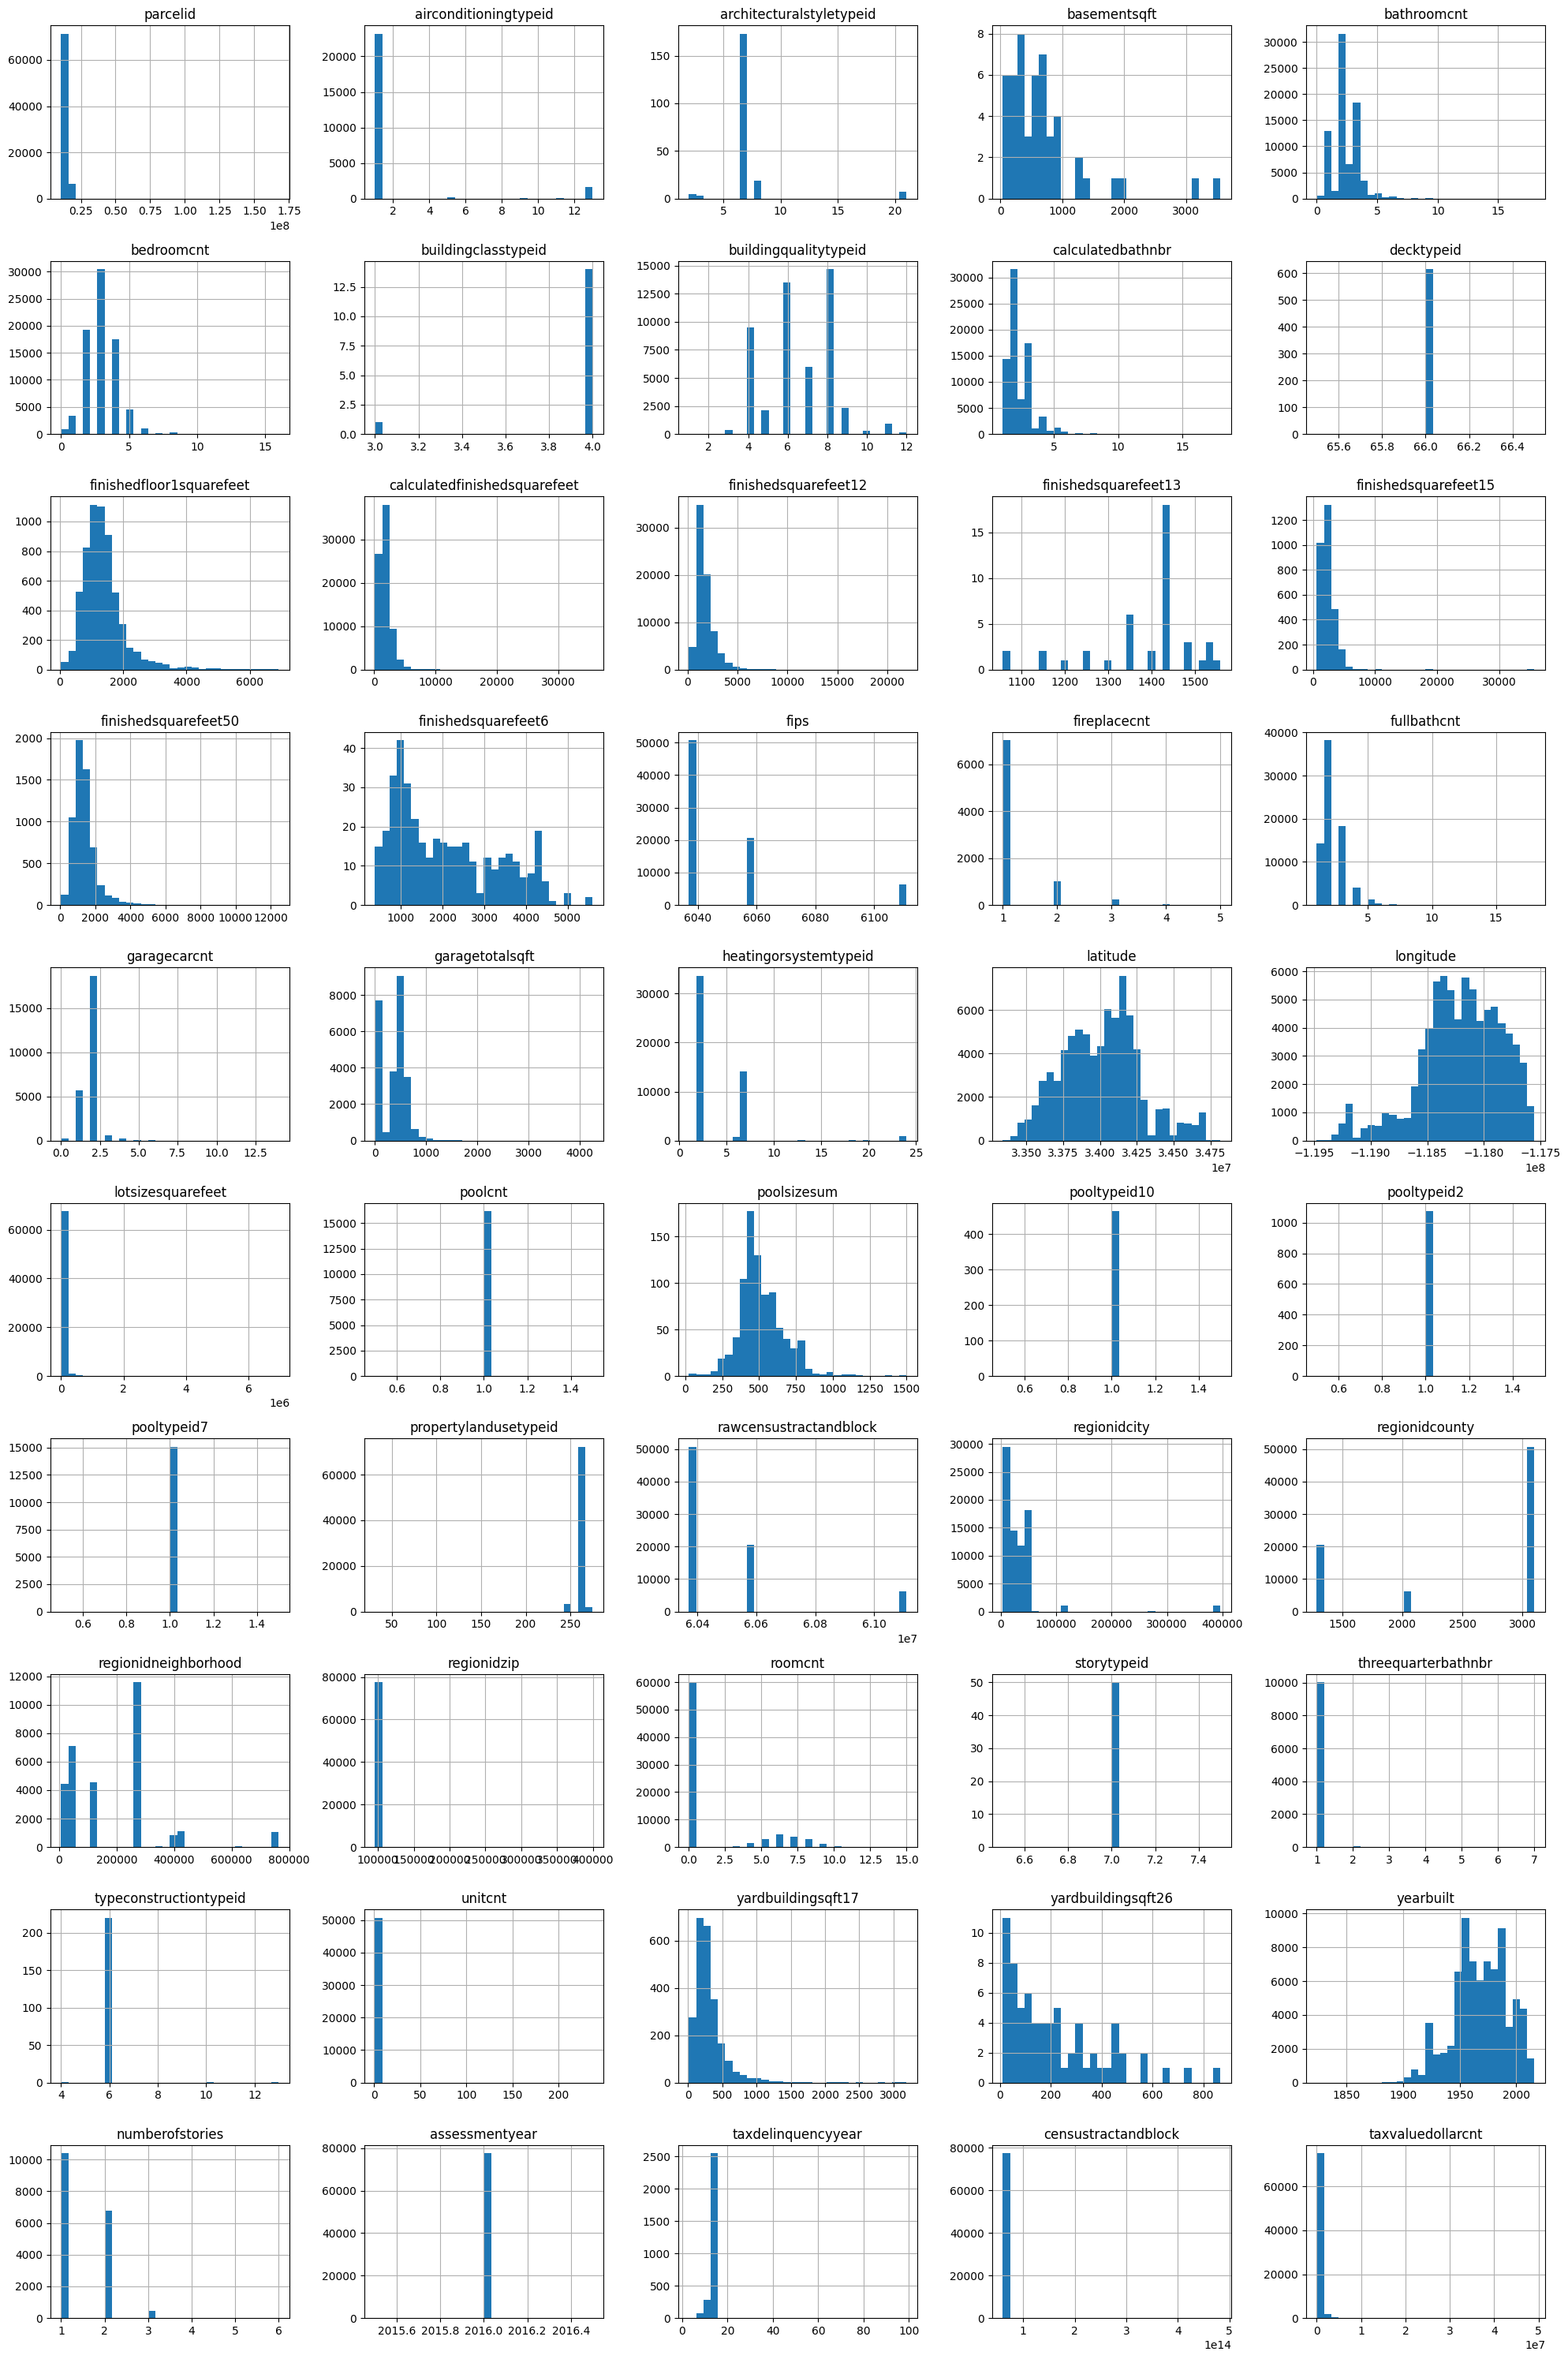

In [7]:
# Generate histograms for all numeric features
df.hist(figsize=(20, 30), layout=(-1, 5), bins=30)
plt.tight_layout()
plt.show()

In [8]:
eda_features = ["taxvaluedollarcnt","calculatedfinishedsquarefeet","bedroomcnt","yearbuilt"]

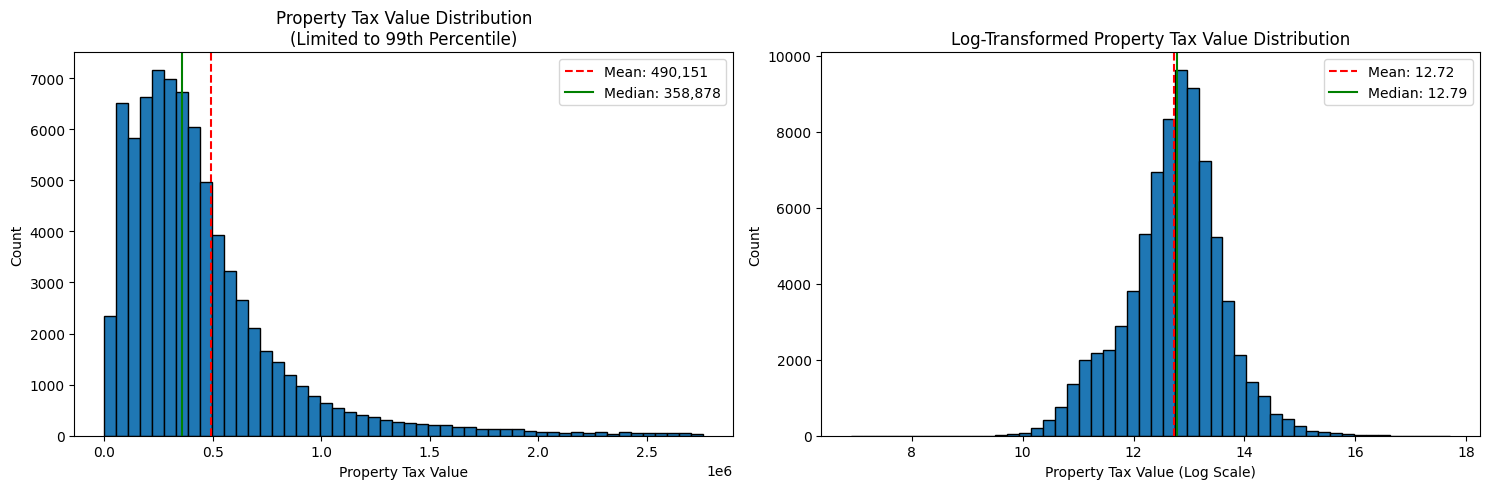

In [9]:
# Compare original and log-transformed target distribution

target = df["taxvaluedollarcnt"].dropna()
log_target = np.log1p(target)

# The original histogram is limited to the 99th percentile to make the main pattern easier to see.
upper_limit = target.quantile(0.99)
target_limited = target[target <= upper_limit]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original target distribution
axes[0].hist(target_limited, bins=50, edgecolor='black')
axes[0].axvline(target.mean(), linestyle="--", color='red', label=f"Mean: {target.mean():,.0f}")
axes[0].axvline(target.median(), linestyle="-", color='green', label=f"Median: {target.median():,.0f}")
axes[0].set_title("Property Tax Value Distribution\n(Limited to 99th Percentile)")
axes[0].set_xlabel("Property Tax Value")
axes[0].set_ylabel("Count")
axes[0].legend()

# Log-transformed target distribution
axes[1].hist(log_target, bins=50, edgecolor='black')
axes[1].axvline(log_target.mean(), linestyle="--", color='red', label=f"Mean: {log_target.mean():.2f}")
axes[1].axvline(log_target.median(), linestyle="-", color='green', label=f"Median: {log_target.median():.2f}")
axes[1].set_title("Log-Transformed Property Tax Value Distribution")
axes[1].set_xlabel("Property Tax Value (Log Scale)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

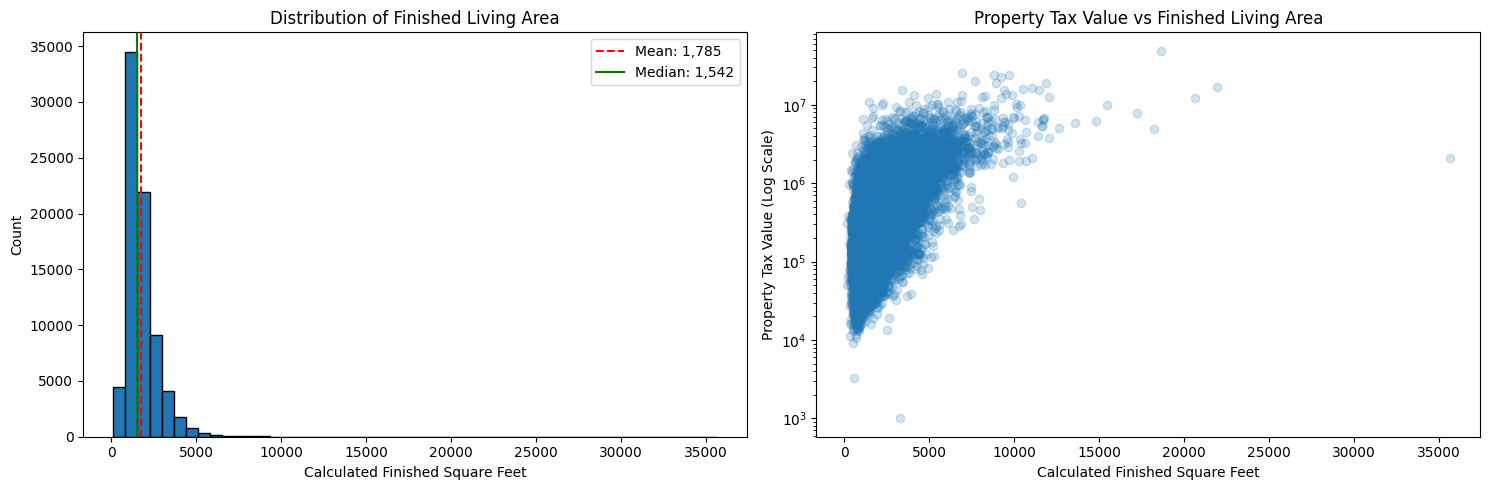

In [10]:
# Examine calculatedfinishedsquarefeet distribution and its relationship with the target.
# use a log scale for the target axis because property tax value is highly right-skewed.

plot_df = df[["calculatedfinishedsquarefeet", "taxvaluedollarcnt"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of calculated finished square feet
axes[0].hist(plot_df["calculatedfinishedsquarefeet"], bins=50, edgecolor="black")
axes[0].axvline(plot_df["calculatedfinishedsquarefeet"].mean(), linestyle="--", color="red", label=f"Mean: {plot_df['calculatedfinishedsquarefeet'].mean():,.0f}")
axes[0].axvline(plot_df["calculatedfinishedsquarefeet"].median(), linestyle="-", color="green", label=f"Median: {plot_df['calculatedfinishedsquarefeet'].median():,.0f}")
axes[0].set_title("Distribution of Finished Living Area")
axes[0].set_xlabel("Calculated Finished Square Feet")
axes[0].set_ylabel("Count")
axes[0].legend()

# Relationship between calculated finished square feet and property tax value
axes[1].scatter(plot_df["calculatedfinishedsquarefeet"], plot_df["taxvaluedollarcnt"], alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_title("Property Tax Value vs Finished Living Area")
axes[1].set_xlabel("Calculated Finished Square Feet")
axes[1].set_ylabel("Property Tax Value (Log Scale)")

plt.tight_layout()
plt.show()

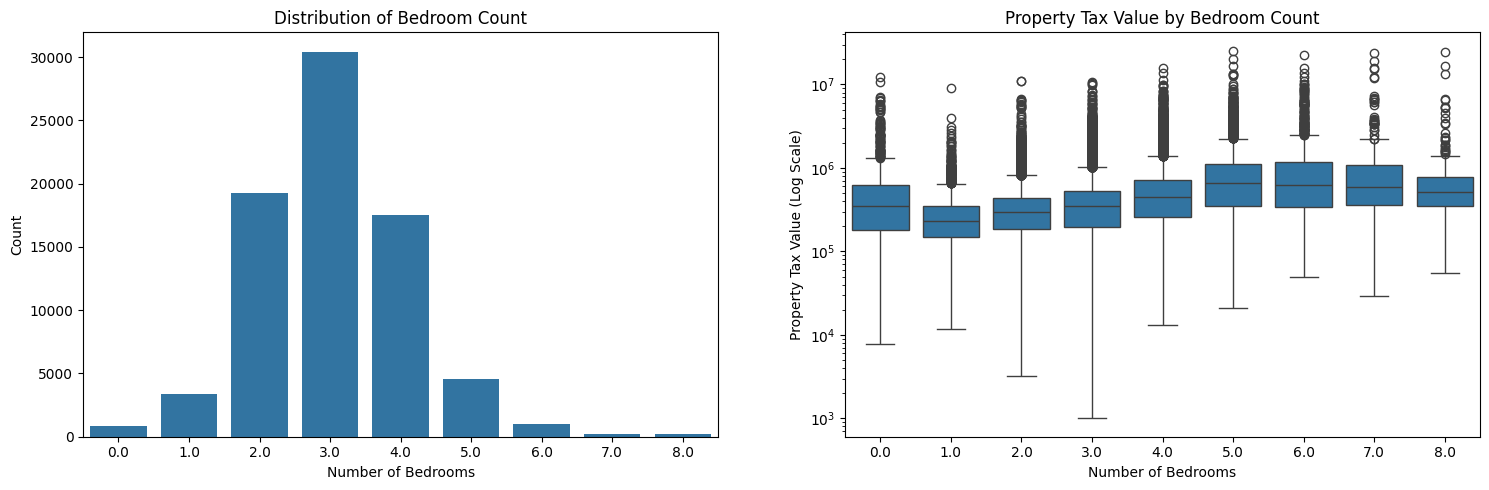

In [11]:
# Examine bedroom count distribution and its relationship with property tax value.
# Bedroom count is a basic property feature and may affect property value.

plot_df = df[["bedroomcnt", "taxvaluedollarcnt"]].dropna()

# Limit bedroom count for readability
plot_df = plot_df[plot_df["bedroomcnt"] <= 8]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of bedroom count
sns.countplot(data=plot_df, x="bedroomcnt", ax=axes[0])
axes[0].set_title("Distribution of Bedroom Count")
axes[0].set_xlabel("Number of Bedrooms")
axes[0].set_ylabel("Count")

# Property tax value by bedroom count
sns.boxplot(data=plot_df, x="bedroomcnt", y="taxvaluedollarcnt", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Property Tax Value by Bedroom Count")
axes[1].set_xlabel("Number of Bedrooms")
axes[1].set_ylabel("Property Tax Value (Log Scale)")

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

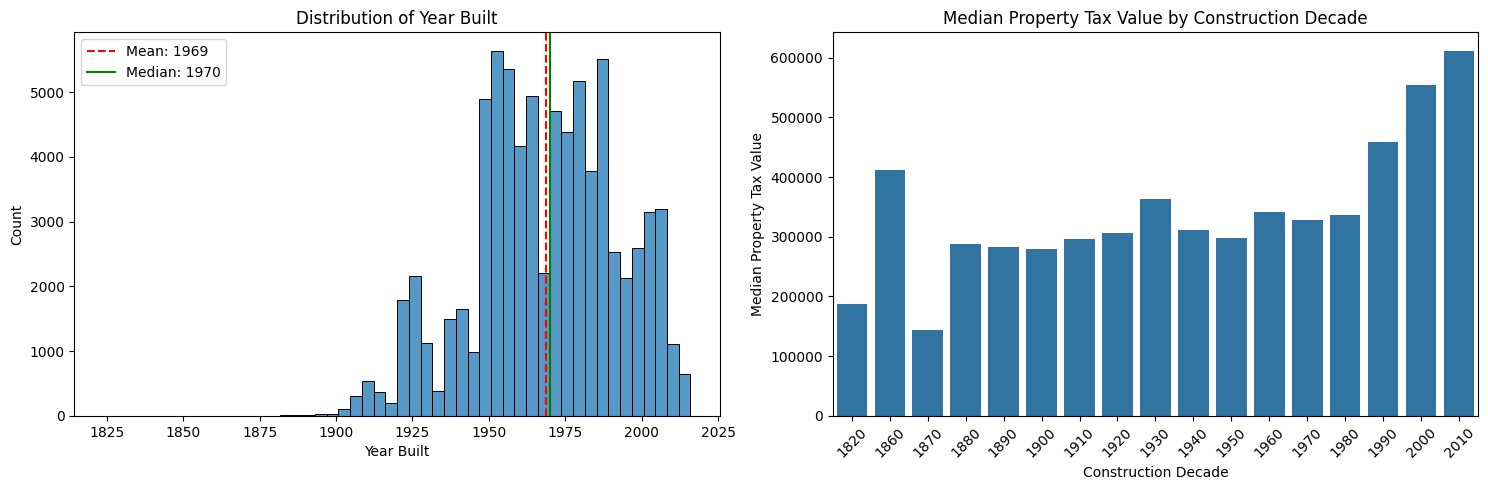

In [12]:
# Examine year built distribution and property tax value by construction decade.
# We group yearbuilt into decades to make the pattern easier to interpret.

plot_df = df[["yearbuilt", "taxvaluedollarcnt"]].dropna().copy()

# Create decade groups
plot_df["yearbuilt_decade"] = (plot_df["yearbuilt"] // 10 * 10).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of year built
sns.histplot(data=plot_df, x="yearbuilt", bins=50, edgecolor="black", ax=axes[0])
axes[0].axvline(plot_df["yearbuilt"].mean(), linestyle="--", color="red", label=f"Mean: {plot_df['yearbuilt'].mean():.0f}")
axes[0].axvline(plot_df["yearbuilt"].median(), linestyle="-", color="green", label=f"Median: {plot_df['yearbuilt'].median():.0f}")
axes[0].set_title("Distribution of Year Built")
axes[0].set_xlabel("Year Built")
axes[0].set_ylabel("Count")
axes[0].legend()

# Median property tax value by decade
decade_median = (plot_df.groupby("yearbuilt_decade")["taxvaluedollarcnt"].median().reset_index())

sns.barplot(data=decade_median,x="yearbuilt_decade",y="taxvaluedollarcnt",ax=axes[1])

axes[1].set_title("Median Property Tax Value by Construction Decade")
axes[1].set_xlabel("Construction Decade")
axes[1].set_ylabel("Median Property Tax Value")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

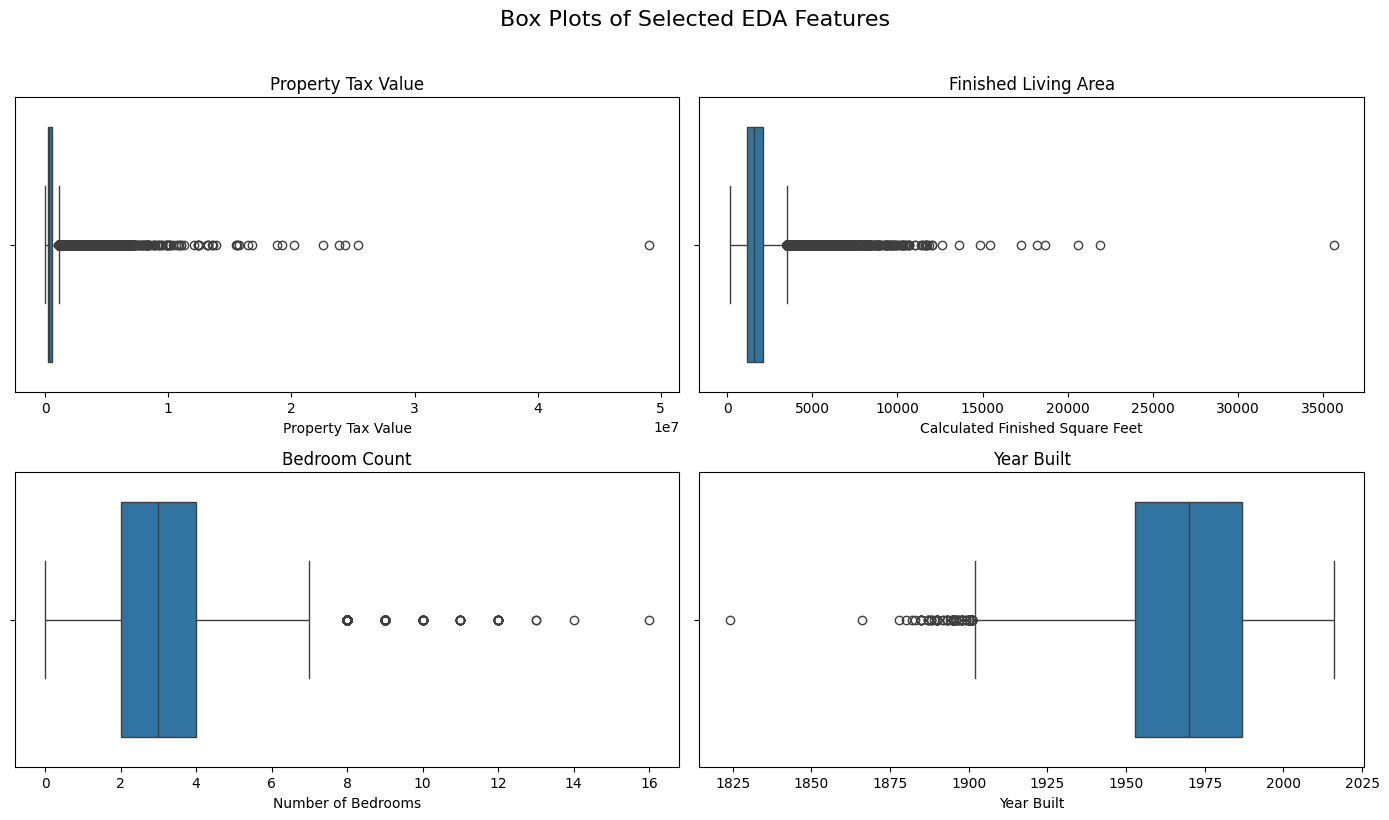

In [13]:
# Box plots of selected EDA features to check outliers

eda_features = ["taxvaluedollarcnt","calculatedfinishedsquarefeet","bedroomcnt","yearbuilt"]

feature_titles = {"taxvaluedollarcnt": "Property Tax Value","calculatedfinishedsquarefeet": "Finished Living Area","bedroomcnt": "Bedroom Count","yearbuilt": "Year Built"}

x_labels = {"taxvaluedollarcnt": "Property Tax Value","calculatedfinishedsquarefeet": "Calculated Finished Square Feet","bedroomcnt": "Number of Bedrooms","yearbuilt": "Year Built"}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(eda_features):
    sns.boxplot(data=df, x=feature, ax=axes[i])
    axes[i].set_title(feature_titles[feature])
    axes[i].set_xlabel(x_labels[feature])

fig.suptitle("Box Plots of Selected EDA Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### **2.B Discussion:** 

Describe what you learned from your detailed examination of the four features you selected. For each feature, discuss:

- The overall distribution (for example, approximately normal, skewed, or multimodal).
- Any notable characteristics, such as outliers, unusual values, or missing data.
- Why you selected the feature and what you learned about the dataset from examining it.

Conclude by briefly discussing whether any of the features you examined might require additional preprocessing later in the project (such as imputation, transformation, or outlier investigation).

> Replace this text with your answer. Organize your discussion by feature, then conclude with your thoughts about possible future preprocessing.

We selected taxvaluedollarcnt, calculatedfinishedsquarefeet, bedroomcnt, and yearbuilt because they are directly related to property value and give different types of information about each property.

- ‍‍`taxvaluedollarcnt`:
taxvaluedollarcnt is our target variable, so we examined it first. The original distribution is strongly right-skewed. Most properties have lower or moderate tax values, but a smaller number of properties have very high tax values. The mean is higher than the median, which shows that high-value properties are pulling the average upward. The log-transformed distribution is easier to read and looks more balanced. This shows that the target has extreme high values, so we may consider a log transformation later, especially if we use a model that is sensitive to skewed target values.

- `calculatedfinishedsquarefeet`:
calculatedfinishedsquarefeet is also right-skewed. Most properties have finished living areas in the lower to middle range, but there are some very large properties. The box plot also shows many high outliers. We selected this feature because the size of the finished living area is one of the most important property characteristics. The scatter plot shows a positive relationship between finished living area and property tax value. In general, larger homes tend to have higher tax values, although there is still a lot of variation. Later, we may need to check extreme square footage values and decide whether they are valid large homes or possible data issues.

- `bedroomcnt`:
bedroomcnt is a count feature, so its distribution is discrete. Most properties have 2, 3, or 4 bedrooms, and 3 bedrooms is the most common. There are also unusual values, such as 0 bedrooms and very high bedroom counts. We selected this feature because the number of bedrooms is a basic property characteristic and may help explain property value. The box plot shows that properties with more bedrooms generally tend to have higher tax values, but there are still many outliers in each bedroom group. Later, we may need to investigate 0-bedroom properties and very high bedroom counts. If those values are rare or not reliable, we may group high bedroom counts together, such as 6 or more bedrooms, or treat unusual values separately.

- `yearbuilt`:
yearbuilt shows when the properties were built. The distribution is not normal. Many properties were built between the 1950s and 1990s, with fewer very old properties. The mean and median are close, around 1969 and 1970. The box plot shows some very old properties as outliers. We selected this feature because property age can affect value. When we grouped yearbuilt into decades, newer construction decades generally showed higher median property tax values, especially after the 1990s. Later, we may transform yearbuilt into a property age feature because age may be easier for a model to use than the raw year.

Conclusion:
Overall, these four features look useful for predicting property tax value, but they may need different preprocessing steps. The target may need a log transformation if we use models that are sensitive to a highly skewed target. calculatedfinishedsquarefeet may need outlier investigation because some homes have extremely large living areas. bedroomcnt may need special handling for 0 bedrooms and very high bedroom counts, possibly by grouping rare high values. yearbuilt has very low missingness, but it may be useful to convert it into property age. These steps would help make the features cleaner and easier to use in modeling.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [14]:
# Drop features that are unsuitable for the regression task.
# These features are removed based on their meaning, not because of missing values.

columns_to_drop_3a = ["parcelid","rawcensustractandblock","censustractandblock","assessmentyear","regionidcounty","regionidneighborhood",
                      "propertycountylandusecode","calculatedbathnbr","fullbathcnt","finishedsquarefeet12","roomcnt","propertyzoningdesc"]

def drop_unsuitable_features(df, columns_to_drop):
    """ drop features that are unsuitable for the regression task based on their meaning,
      not because of missing values. """

    df_clean = df.copy()
    
    existing_columns_to_drop = [col for col in columns_to_drop if col in df_clean.columns]
    
    df_clean = df_clean.drop(columns=existing_columns_to_drop)
    
    return df_clean, existing_columns_to_drop

df_3a, dropped_3a = drop_unsuitable_features(df, columns_to_drop_3a)

print("Original shape:", df.shape)
print("After Part 3.A:", df_3a.shape)
print("Dropped columns:", dropped_3a)

Original shape: (77613, 55)
After Part 3.A: (77613, 43)
Dropped columns: ['parcelid', 'rawcensustractandblock', 'censustractandblock', 'assessmentyear', 'regionidcounty', 'regionidneighborhood', 'propertycountylandusecode', 'calculatedbathnbr', 'fullbathcnt', 'finishedsquarefeet12', 'roomcnt', 'propertyzoningdesc']


#### **3.A Discussion:**

Describe the features you chose to remove, if any, and justify each decision. For each feature, explain:

- Why you believed it was unsuitable for predicting the target.
- Which characteristic led to your decision (for example, an identifier, irrelevant information, or another reason).
- Why your decision was based on the feature's meaning rather than the amount of missing data.

If you chose not to remove any features, explain why.

We removed several features because they were not suitable as direct predictors for the regression task. These decisions were based on the meaning and structure of the features, not on the amount of missing data.

- `parcelid` because it is a unique identifier for each property. It helps identify the row, but it does not describe the property itself.

- `rawcensustractandblock` and `censustractandblock` because they are very specific location identifier codes. They may be useful for lookup, but they work more like IDs than regular model features.

- `assessmentyear` because almost all rows have the same value, 2016. Since it has almost no variation, it does not help the model distinguish between properties.

- `regionidcounty` because it overlaps with fips. Both features describe county-level location information, so keeping both would be repetitive.

- `regionidneighborhood` because it is a detailed location code that overlaps with other location features such as latitude, longitude, regionidcity, regionidzip, and fips. It also has many possible categories, which would make encoding more complex.

- `propertycountylandusecode` because it overlaps with propertylandusetypeid. Both features describe land use information, but propertylandusetypeid gives a cleaner land use category for modeling.

- `calculatedbathnbr` and `fullbathcnt` because they overlap with bathroomcnt. We kept bathroomcnt because it gives the main bathroom count.

- `finishedsquarefeet12` because it overlaps with calculatedfinishedsquarefeet. We kept calculatedfinishedsquarefeet because it gives the main finished living area.

- `roomcnt` because it does not appear reliable in this dataset. Most rows have a value of 0, which is unusual for residential properties. It also overlaps with better property features such as bedroomcnt, bathroomcnt, and calculatedfinishedsquarefeet.

- `propertyzoningdesc` because it has many unique zoning categories, which would make encoding difficult and sparse.

Overall, we removed these features because they were identifiers, repetitive with other features, almost constant, unreliable, or difficult to encode directly. We did not remove them because of missing values.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [15]:
# Check missing percentages after Part 3.A

missing_pct_3a = (df_3a.isna().mean()*100).sort_values(ascending=False)

missing_pct_3a.head(30)

buildingclasstypeid         99.980673
finishedsquarefeet13        99.945885
basementsqft                99.935578
storytypeid                 99.935578
yardbuildingsqft26          99.909809
fireplaceflag               99.778388
architecturalstyletypeid    99.733292
typeconstructiontypeid      99.712677
finishedsquarefeet6         99.502661
pooltypeid10                99.400874
decktypeid                  99.208895
poolsizesum                 98.880342
pooltypeid2                 98.616211
hashottuborspa              98.017085
yardbuildingsqft17          96.916754
taxdelinquencyflag          96.263513
taxdelinquencyyear          96.263513
finishedsquarefeet15        96.099880
finishedfloor1squarefeet    92.221664
finishedsquarefeet50        92.221664
fireplacecnt                89.320088
threequarterbathnbr         86.978985
pooltypeid7                 80.571554
poolcnt                     79.160708
numberofstories             77.324675
airconditioningtypeid       67.779882
garagecarcnt

In [16]:
# Drop features with too many missing values.
# We use 60% missing as the main threshold.
# Some sparse features are kept because we plan to handle them later with imputation or indicators.

missing_threshold = 60

keep_even_if_missing = ["poolcnt","hashottuborspa","taxdelinquencyflag"]

def drop_high_missing_features(df, threshold=60, keep_columns=None):
    df_clean = df.copy()
    
    if keep_columns is None:
        keep_columns = []
    
    missing_pct = df_clean.isna().mean() * 100
    
    high_missing_cols = missing_pct[missing_pct > threshold].index.tolist()
    
    columns_to_drop = [col for col in high_missing_cols if col not in keep_columns]
    
    df_clean = df_clean.drop(columns=columns_to_drop)
    
    return df_clean, columns_to_drop, missing_pct

df_3b, dropped_3b, missing_pct_3b = drop_high_missing_features(
    df_3a,
    threshold=missing_threshold,
    keep_columns=keep_even_if_missing
)

print("After Part 3.A:", df_3a.shape)
print("After Part 3.B:", df_3b.shape)
print("Dropped columns:", dropped_3b)

After Part 3.A: (77613, 43)
After Part 3.B: (77613, 18)
Dropped columns: ['airconditioningtypeid', 'architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'garagecarcnt', 'garagetotalsqft', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'numberofstories', 'fireplaceflag', 'taxdelinquencyyear']


#### **3.B Discussion:**

Describe the criteria you used to decide which features had **too many** missing values to retain.

In particular, explain:

- The threshold you selected for determining when a feature should be removed.
- Why you believe this threshold was appropriate for this dataset.
- Whether you considered the usefulness of the remaining non-null values before deciding to remove a feature, and how this influenced your decision.

We removed features that had too many missing values. We used 60% missing values as our main threshold. This means that if more than 60% of a feature was missing, we usually removed it.

We chose 60% as the threshold because this dataset has many special property-detail columns. Some of these features are only recorded for a small group of properties. If more than 60% of a feature is missing, then most rows would need imputed values instead of real values. We believed this was too much missing information for reliable modeling, so 60% was a reasonable cutoff for this dataset.

We also looked at what each feature means before removing it. We kept poolcnt, hashottuborspa, and taxdelinquencyflag even though they had many missing values. These columns are useful because they act like indicator features. They tell us whether a property has a pool, hot tub or spa, or tax delinquency. Because of that, we decided to keep them and handle their missing values later.

We removed garagecarcnt and garagetotalsqft because both had more than 60% missing values. Garage information could be useful, but most of the values were missing, so we decided not to impute most of these columns.

Most of the features we removed in this step were very sparse property-detail columns. These included features about basement size, architectural style, construction type, fireplace count, garage information, pool subtypes, yard building square footage, and detailed finished-square-footage types. Since these columns only gave information for a small part of the dataset, we removed them before the imputation step.

### Part 3.C: Remove Problematic Samples

Some samples may not be suitable for model training because they contain insufficient information or cannot be used for supervised learning.

- Remove any sample with a missing target value.
- Decide on a reasonable threshold for the maximum percentage of missing feature values in a sample, justify your choice, and remove samples exceeding that threshold.
- Investigate whether the dataset contains potential outliers, but **do not remove them yet.** Instead, describe how you identified them and explain why removing them may or may not be appropriate. Their effect on model performance will be investigated in Milestone 2.

Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [17]:
# Remove rows with missing target values

target_col = "taxvaluedollarcnt"

df_3c_start = df_3b.copy()

missing_target_count = df_3c_start[target_col].isna().sum()

df_3c_no_missing_target = df_3c_start.dropna(subset=[target_col]).copy()

print("Rows with missing target removed:", missing_target_count)
print("Shape after removing missing target:", df_3c_no_missing_target.shape)

Rows with missing target removed: 35
Shape after removing missing target: (77578, 18)


In [18]:
# Check missing percentage per row, excluding the target column

feature_cols = df_3c_no_missing_target.columns.drop(target_col)

row_missing_pct = df_3c_no_missing_target[feature_cols].isna().mean(axis=1) * 100

row_missing_pct.describe()

count    77578.000000
mean        23.128449
std          9.646884
min          5.882353
25%         17.647059
50%         17.647059
75%         35.294118
max         64.705882
dtype: float64

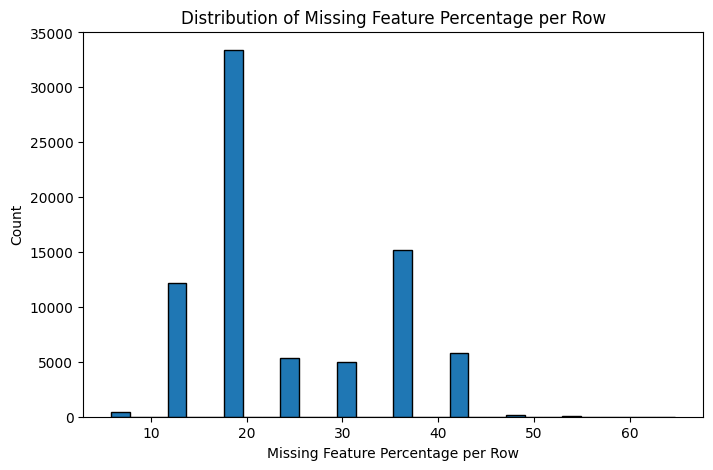

In [19]:
# Plot missing percentage per row

plt.figure(figsize=(8, 5))
plt.hist(row_missing_pct, bins=30, edgecolor="black")
plt.xlabel("Missing Feature Percentage per Row")
plt.ylabel("Count")
plt.title("Distribution of Missing Feature Percentage per Row")
plt.show()

In [20]:
# Remove rows with more than 50% missing feature values

row_missing_threshold = 50

rows_to_drop_missing = row_missing_pct > row_missing_threshold

df_3c = df_3c_no_missing_target.loc[~rows_to_drop_missing].copy()

print("Rows removed for too much missing feature data:", rows_to_drop_missing.sum())
print("Shape after Part 3.C:", df_3c.shape)

Rows removed for too much missing feature data: 91
Shape after Part 3.C: (77487, 18)


In [21]:
# Investigate potential outliers using the IQR rule.
# We only identify outliers here. We do not remove them in Milestone 1.

outlier_features = ["taxvaluedollarcnt","calculatedfinishedsquarefeet","lotsizesquarefeet","bedroomcnt","yearbuilt"]

outlier_features = [col for col in outlier_features if col in df_3c.columns]

outlier_summary = []

for col in outlier_features:
    series = df_3c[col].dropna()
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()
    outlier_pct = outlier_count / len(series) * 100
    
    outlier_summary.append({
        "feature": col,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_pct": outlier_pct,
        "min": series.min(),
        "max": series.max()
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,feature,lower_bound,upper_bound,outlier_count,outlier_pct,min,max
0,taxvaluedollarcnt,-336046.50,1112077.50,5180,6.684992,1000.0,49061236.0
1,calculatedfinishedsquarefeet,-213.00,3507.00,4004,5.174999,128.0,35640.0
2,lotsizesquarefeet,-3503.25,21038.75,11406,16.456262,236.0,6971010.0
3,bedroomcnt,-1.00,7.00,383,0.494276,0.0,16.0
4,yearbuilt,1902.00,2038.00,113,0.146170,1824.0,2016.0


#### **3.C Discussion:**

Describe your decisions about which samples were removed and why.

In particular, discuss:

- The criteria you used to identify samples that should be removed (for example, missing target values or excessive missing data).
- If you identified potential outliers, explain how you identified them and why you chose to retain them at this stage.
- The potential advantages and disadvantages of removing outliers, and why you believe this decision should be evaluated experimentally in **Milestone 2**.

We removed samples that were not useful for model training. First, we removed rows where the target variable, taxvaluedollarcnt, was missing. Since this is a supervised regression problem, a row without the target value cannot be used for training.

Next, we checked the percentage of missing feature values in each row. We used 50% as our threshold. If more than half of the remaining feature values in a row were missing, we removed that sample. We chose this threshold because a row with more than half of its information missing would not give the model enough real information. Keeping those rows would require too much imputation.

We also investigated possible outliers, but we did not remove them at this stage. We used the IQR rule to check important features such as taxvaluedollarcnt, calculatedfinishedsquarefeet, lotsizesquarefeet, bedroomcnt, and yearbuilt. This helped us identify possible extreme values, such as very high property values, very large homes, very large lot sizes, unusual bedroom counts, or very old properties.

We kept the outliers for now because some of them may be real properties, not data errors. Removing outliers could make the data cleaner, but it could also remove important real examples. Because of this, we will evaluate the effect of outliers on model performance in Milestone 2 instead of removing them in this milestone.

### Part 3.D: Split the Dataset into Training and Test Sets

Now that the initial data cleaning is complete, split the dataset into training and test sets.

Use:

- test_size=0.20
- random_state=42

The remaining preprocessing steps should be learned **only from the training set** and then applied unchanged to the test set. This prevents information from the test set from influencing the training process ("data leakage"). 

No discussion necessary. 

Before splitting the data, we dropped rows with missing values in a few features that had very small missing percentages. This follows Appendix 2, which recommends dropping missing values when only a small percentage of the data is missing. We did this before the train-test split so the final 80/20 split would be created from the same cleaned dataset and the train/test ratio would not change later.

This step is not an imputation step. We are not learning any mean, median, mode, or model from the full dataset. All remaining missing values after the split will be imputed using methods fitted only on the training set.

In [22]:
# Review remaining missing values before the train-test split

feature_df = df_3c.drop(columns=["taxvaluedollarcnt"])

pre_split_missing_summary = pd.DataFrame({
    "missing_count": feature_df.isna().sum(),
    "missing_pct": feature_df.isna().mean() * 100,
    "unique_values": feature_df.nunique(dropna=True),
    "dtype": feature_df.dtypes})

pre_split_missing_summary = (
    pre_split_missing_summary
    .loc[pre_split_missing_summary["missing_count"] > 0]
    .sort_values(by="missing_pct", ascending=False))

pre_split_missing_summary

,missing_count,missing_pct,unique_values,dtype
hashottuborspa,75948,98.013860,1,object
taxdelinquencyflag,74588,96.258727,1,object
poolcnt,61314,79.128112,1,float64
heatingorsystemtypeid,27916,36.026688,10,float64
buildingqualitytypeid,27678,35.719540,12,float64
unitcnt,26784,34.565798,8,float64
lotsizesquarefeet,8176,10.551447,18846,float64
regionidcity,1455,1.877734,175,float64
yearbuilt,180,0.232297,136,float64
calculatedfinishedsquarefeet,115,0.148412,4972,float64


In [23]:
# Drop rows with missing values in low-missing features before the train-test split
low_missing_threshold = 5
low_missing_drop_cols = pre_split_missing_summary[pre_split_missing_summary["missing_pct"] < low_missing_threshold].index.tolist()  
df_3d_ready = df_3c.dropna(subset=low_missing_drop_cols).copy()

print("Low-missing columns used for row dropping:", low_missing_drop_cols)
print("Shape before dropping low-missing rows:", df_3c.shape)
print("Shape after dropping low-missing rows:", df_3d_ready.shape)
print("Rows removed:", df_3c.shape[0] - df_3d_ready.shape[0])

Low-missing columns used for row dropping: ['regionidcity', 'yearbuilt', 'calculatedfinishedsquarefeet', 'regionidzip']
Shape before dropping low-missing rows: (77487, 18)
Shape after dropping low-missing rows: (75831, 18)
Rows removed: 1656


In [24]:
# Convert yearbuilt to property age using the assessment year 2016
assessment_year = 2016
df_3d_ready["property_age"] = assessment_year - df_3d_ready["yearbuilt"]
df_3d_ready = df_3d_ready.drop(columns=["yearbuilt"])

# Convert latitude and longitude to regular coordinate scale
geo_cols = ["latitude", "longitude"]
df_3d_ready[geo_cols] = df_3d_ready[geo_cols] / 1_000_000

In [25]:
# split the dataset into training and testing sets.
target_col = "taxvaluedollarcnt"
X = df_3d_ready.drop(columns=[target_col])
y = df_3d_ready[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60664, 17)
X_test shape: (15167, 17)
y_train shape: (60664,)
y_test shape: (15167,)


In [26]:
# Save train and test sets before imputation and encoding
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

### Part 3.E: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Fit your imputation method(s) using only the training data.
- Apply the fitted imputer(s) to both the training and test sets so that no missing values remain.
- Answer the discussion question.


In [27]:
# Check missing values after train-test split

missing_after_split = pd.DataFrame({
    "train_missing_count": X_train.isna().sum(),
    "train_missing_pct": X_train.isna().mean() * 100,
    "test_missing_count": X_test.isna().sum(),
    "test_missing_pct": X_test.isna().mean() * 100,
    "train_unique_values": X_train.nunique(dropna=True),
    "test_unique_values": X_test.nunique(dropna=True),
    "dtype": X_train.dtypes
})

missing_after_split = (
    missing_after_split[
        (missing_after_split["train_missing_count"] > 0) |
        (missing_after_split["test_missing_count"] > 0)
    ]
    .sort_values(by="train_missing_pct", ascending=False)
)

missing_after_split

,train_missing_count,train_missing_pct,test_missing_count,test_missing_pct,train_unique_values,test_unique_values,dtype
hashottuborspa,59500,98.081234,14862,97.989055,1,1,object
taxdelinquencyflag,58368,96.215218,14619,96.386893,1,1,object
poolcnt,48048,79.203481,11979,78.980682,1,1,float64
heatingorsystemtypeid,21844,36.008176,5489,36.190413,10,8,float64
buildingqualitytypeid,21651,35.690030,5451,35.939869,12,12,float64
unitcnt,20966,34.560860,5275,34.779455,5,7,float64
lotsizesquarefeet,6448,10.629039,1581,10.423947,16769,7699,float64


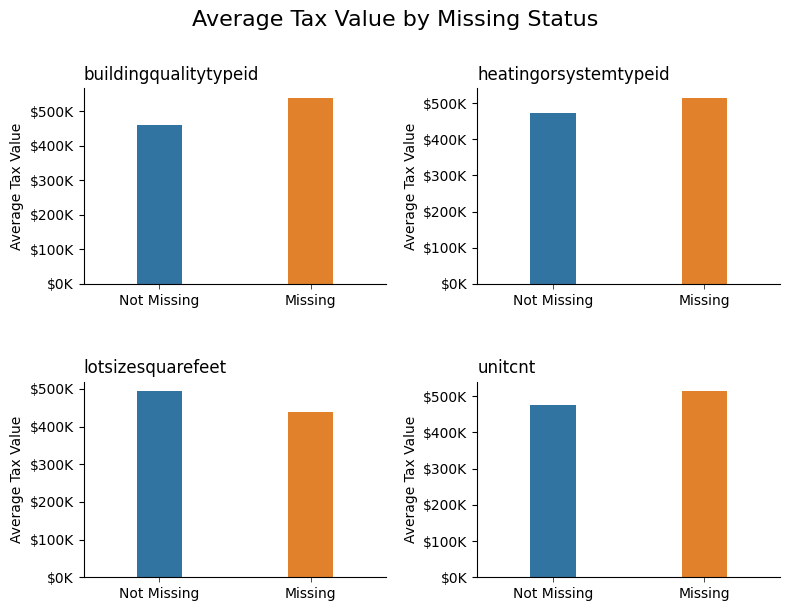

In [28]:
# Visualize the relationship between missing values and the target variable.
# We use this plot to check whether missingness may be informative before choosing imputation methods.
# We exclude poolcnt, hashottuborspa, and taxdelinquencyflag from this plot because they are indicator-style features.
# For those columns, a recorded value means the feature is present, and missing values will be converted to 0 later.

from matplotlib.ticker import FuncFormatter
# dollar_format function is used to format the y-axis labels as dollars in thousands (K).

def dollar_format(x, pos):
    return f"${x/1000:,.0f}K"

# Merge the training data with the target variable
x_train_df = X_train.merge(y_train, left_index=True, right_index=True)
indicator_cols = ["hashottuborspa","poolcnt","taxdelinquencyflag"]
missing_cols = X_train.columns[X_train.isna().sum() > 0]
missing_cols = [col for col in missing_cols if col not in indicator_cols]

# Create subplots for each feature with missing values
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()
fig.suptitle("Average Tax Value by Missing Status", fontsize=16, y=1.01)
for i, col in enumerate(missing_cols):
    missing_patterns = x_train_df.groupby(x_train_df[col].isna())["taxvaluedollarcnt"].mean()
    missing_patterns.index = missing_patterns.index.map({False: "Not Missing", True: "Missing"})
    sns.barplot(x=missing_patterns.index, y=missing_patterns.values, ax=axes[i], width=0.3, hue = missing_patterns.index)
    axes[i].set_title(f"{col}", loc = "left")
    axes[i].set_xlabel(None)
    axes[i].yaxis.set_major_formatter(FuncFormatter(dollar_format))
    axes[i].set_ylabel("Average Tax Value")
    axes[i].tick_params(axis="x", width=0.5, rotation=0)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(True)
    axes[i].spines['bottom'].set_visible(True)

# remove empty subplots
for j in range(len(missing_cols), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)  
plt.show()
    

In [29]:
# Impute indicator-style features: missing = 0, recorded value = 1
def impute_indicator_features(X_train, X_test, indicator_cols):
    """Convert indicator-style missing values to 0 and recorded values to 1."""

    X_train_clean = X_train.copy()
    X_test_clean = X_test.copy()
    
    indicator_cols = [col for col in indicator_cols if col in X_train_clean.columns]
    
    for col in indicator_cols:
        X_train_clean[col] = X_train_clean[col].notna().astype(int)
        X_test_clean[col] = X_test_clean[col].notna().astype(int)
    
    return X_train_clean, X_test_clean


# Impute selected features with the training-set median
def impute_with_median(X_train, X_test, median_cols):
    """Impute selected columns using medians fitted on the training set."""
    
    X_train_clean = X_train.copy()
    X_test_clean = X_test.copy()
    
    median_cols = [col for col in median_cols if col in X_train_clean.columns]
    
    median_imputer = SimpleImputer(strategy="median")
    
    if len(median_cols) > 0:
        X_train_clean[median_cols] = median_imputer.fit_transform(X_train_clean[median_cols])
        X_test_clean[median_cols] = median_imputer.transform(X_test_clean[median_cols])
    
    return X_train_clean, X_test_clean, median_imputer


# Impute categorical code features with "Unknown"
def impute_with_unknown(X_train, X_test, unknown_cols):
    """Fill missing categorical code values with 'Unknown'."""
    
    X_train_clean = X_train.copy()
    X_test_clean = X_test.copy()
    
    unknown_cols = [col for col in unknown_cols if col in X_train_clean.columns]
    
    unknown_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")
    
    if len(unknown_cols) > 0:
        X_train_clean[unknown_cols] = X_train_clean[unknown_cols].astype("object")
        X_test_clean[unknown_cols] = X_test_clean[unknown_cols].astype("object")
        
        X_train_clean[unknown_cols] = unknown_imputer.fit_transform(X_train_clean[unknown_cols])
        X_test_clean[unknown_cols] = unknown_imputer.transform(X_test_clean[unknown_cols])
        
        X_train_clean[unknown_cols] = X_train_clean[unknown_cols].astype(str)
        X_test_clean[unknown_cols] = X_test_clean[unknown_cols].astype(str)
    
    return X_train_clean, X_test_clean, unknown_imputer

We used different imputation methods based on the feature type and Appendix 2. Indicator-style features were converted to 0/1.  
Numerical and ordinal numeric features were imputed with the training-set median.  
The heating system type was treated as a categorical code, so missing values were filled with "Unknown".   
All imputation methods were fitted only on the training set and then applied to the test set.

In [30]:
# Create copies for imputation
X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

In [31]:
# Impute missing values in the training and testing sets using the defined functions.

indicator_cols = ["hashottuborspa","poolcnt","taxdelinquencyflag"]
median_cols = ["buildingqualitytypeid","unitcnt","lotsizesquarefeet"]
unknown_cols = ["heatingorsystemtypeid"]

X_train_imputed, X_test_imputed = impute_indicator_features(X_train_imputed,X_test_imputed,indicator_cols)
X_train_imputed, X_test_imputed, median_imputer = impute_with_median(X_train_imputed,X_test_imputed,median_cols)
X_train_imputed, X_test_imputed, unknown_imputer = impute_with_unknown(X_train_imputed,X_test_imputed,unknown_cols)


In [32]:
# Final checks after imputation and basic numerical transformations
print("Missing values in X_train:", X_train_imputed.isna().sum().sum())
print("Missing values in X_test:", X_test_imputed.isna().sum().sum())
print("Shape of X_train:", X_train_imputed.shape)
print("Shape of X_test:", X_test_imputed.shape)

Missing values in X_train: 0
Missing values in X_test: 0
Shape of X_train: (60664, 17)
Shape of X_test: (15167, 17)


In [33]:
X_train_imputed.to_csv("X_train_imputed.csv", index=False)
X_test_imputed.to_csv("X_test_imputed.csv", index=False)

#### **3.E Discussion:**

Describe your overall imputation strategy.

In particular, explain:

- Which imputation method(s) you selected.
- Why each method was appropriate for the feature(s) to which it was applied.
- Whether you used different strategies for different types of features (for example, numerical versus categorical, or approximately normal versus skewed numerical features), and why.

We used different imputation strategies based on the feature type and the meaning of the missing values.

Before this step, we dropped rows with missing values in features that had very small missing percentages. After the train-test split, we handled the remaining missing values using imputation methods fitted only on the training set and then applied to both the training and test sets.

For the indicator-style features, including `poolcnt`, `hashottuborspa`, and `taxdelinquencyflag`, we converted missing values to 0 and recorded values to 1. We used this method because these columns mainly show whether a feature was recorded as present. For example, a recorded pool value means the property has a pool, while a missing value means there is no recorded evidence of a pool.

For `buildingqualitytypeid`, we used median imputation. We treated this feature as an ordinal categorical feature because it represents building quality, and higher values usually indicate better quality. Since the values have an order, the median was a reasonable way to fill missing values.

For `unitcnt`, we also used median imputation. We treated this feature as a discrete numerical count because it represents the number of units in the property. Since most properties are likely to have a small number of units and only a smaller number have many units, the distribution can be skewed. The median is more appropriate than the mean for this type of feature.

For `lotsizesquarefeet`, we used median imputation because it is a continuous numerical feature and its distribution is right-skewed with large outliers. The median is less affected by extreme lot sizes than the mean.

For `heatingorsystemtypeid`, we used an `"Unknown"` category. This feature is a categorical code, not a true numerical measurement, so mean or median imputation would not be meaningful. It also had a relatively high missing percentage, and the missing group showed a different average target value in our missingness plot. Because of this, we treated missing values as a separate `"Unknown"` category instead of forcing many rows into the most common heating type.

Before the train-test split, we also made two basic numerical transformations. We converted `yearbuilt` into `property_age` using the assessment year 2016, because property age is easier to interpret than the original build year. We also divided `latitude` and `longitude` by 1,000,000 because they were stored as large integer coordinate values. This converted them into regular geographic coordinate values.

Overall, we used separate imputation methods for indicator-style features, ordinal features, numerical count features, continuous numerical features, and categorical code features. This helped us choose methods that matched the meaning of each feature while avoiding data leakage.

### 3.F: Encode the Categorical Features (if any)

Refer to Appendix 3 for a summary of feature types and appropriate encoding strategies.

- Identify any categorical features that remain after your earlier preprocessing. For each feature, determine whether it is nominal or ordinal, then choose an appropriate encoding method. Use ordinal encoding only for features with a meaningful ordering, and one-hot encoding for nominal features with no natural ordering.

- Fit the encoder(s) using only the training data, then apply the fitted encoder(s) to both the training and test sets. Some teams may have very few categorical features remaining after the earlier cleaning steps.

**Note:** Many categorical features in this dataset are represented by numeric identifier codes (for example, `propertylandusetypeid`). Do not assume that a feature is numerical simply because its data type is int or float. Instead, use the feature descriptions in Appendix 1 and flowchart in Appendix 3 to determine whether the feature represents a numerical measurement or a categorical variable.

In [34]:
# Start Part 3.F from the imputed non-encoded data
X_train_encoded = X_train_imputed.copy()
X_test_encoded = X_test_imputed.copy()

In [35]:
# Define categorical feature groups
# Target encoding for location features with many unique values
target_encode_cols = ["regionidcity", "regionidzip"]

# One-hot encoding for nominal categorical features with few unique values
one_hot_cols = ["fips", "propertylandusetypeid", "heatingorsystemtypeid"]

print("Target encoding columns:", target_encode_cols)
print("One-hot encoding columns:", one_hot_cols)

Target encoding columns: ['regionidcity', 'regionidzip']
One-hot encoding columns: ['fips', 'propertylandusetypeid', 'heatingorsystemtypeid']


In [36]:
# Target encoding for features with many unique values

from sklearn.preprocessing import TargetEncoder

# Convert target-encoded categorical columns to string
X_train_encoded[target_encode_cols] = X_train_encoded[target_encode_cols].astype(str)
X_test_encoded[target_encode_cols] = X_test_encoded[target_encode_cols].astype(str)

# Apply target encoding to the specified columns using the training set and transform both training and testing sets.
target_encoder = TargetEncoder(target_type="continuous",smooth=50,cv=5,shuffle=True,random_state=42)
X_train_te = target_encoder.fit_transform(X_train_encoded[target_encode_cols],y_train)
X_test_te = target_encoder.transform(X_test_encoded[target_encode_cols])

# Create DataFrames for the target-encoded columns with appropriate column names and indices
target_encoded_names = [col + "_te" for col in target_encode_cols]
X_train_te_df = pd.DataFrame(X_train_te,columns=target_encoded_names,index=X_train_encoded.index)
X_test_te_df = pd.DataFrame(X_test_te,columns=target_encoded_names,index=X_test_encoded.index)

# Drop original high-cardinality columns and add target-encoded columns
X_train_encoded = X_train_encoded.drop(columns=target_encode_cols)
X_test_encoded = X_test_encoded.drop(columns=target_encode_cols)

# Concatenate the target-encoded DataFrames to the main training and testing DataFrames
X_train_encoded = pd.concat([X_train_encoded, X_train_te_df], axis=1)
X_test_encoded = pd.concat([X_test_encoded, X_test_te_df], axis=1)


In [37]:
# One-hot encoding for features with few unique values
from sklearn.preprocessing import OneHotEncoder

# Convert low-cardinality categorical codes to string
X_train_encoded[one_hot_cols] = X_train_encoded[one_hot_cols].astype(str)
X_test_encoded[one_hot_cols] = X_test_encoded[one_hot_cols].astype(str)

# One-hot encode the selected categorical features
one_hot_encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)
X_train_ohe = one_hot_encoder.fit_transform(X_train_encoded[one_hot_cols])
X_test_ohe = one_hot_encoder.transform(X_test_encoded[one_hot_cols])

# Create DataFrames for the one-hot encoded features with appropriate column names
one_hot_feature_names = one_hot_encoder.get_feature_names_out(one_hot_cols)
X_train_ohe_df = pd.DataFrame(X_train_ohe,columns=one_hot_feature_names,index=X_train_encoded.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe,columns=one_hot_feature_names,index=X_test_encoded.index)

# Drop original one-hot columns and add encoded columns
X_train_encoded = X_train_encoded.drop(columns=one_hot_cols)
X_test_encoded = X_test_encoded.drop(columns=one_hot_cols)

# Concatenate the one-hot encoded DataFrames to the main DataFrames
X_train_encoded = pd.concat([X_train_encoded, X_train_ohe_df], axis=1)
X_test_encoded = pd.concat([X_test_encoded, X_test_ohe_df], axis=1)

In [38]:
print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)

print("Missing values in X_train_encoded:", X_train_encoded.isna().sum().sum())
print("Missing values in X_test_encoded:", X_test_encoded.isna().sum().sum())

X_train_encoded shape: (60664, 41)
X_test_encoded shape: (15167, 41)
Missing values in X_train_encoded: 0
Missing values in X_test_encoded: 0


In [39]:
X_train_encoded.to_csv("X_train_encoded.csv", index=False)
X_test_encoded.to_csv("X_test_encoded.csv", index=False)

#### **3.F Discussion:**

Describe the categorical features that remained after your earlier preprocessing.

In particular, discuss:

- Which features you identified as categorical.
- Whether each feature is **nominal** or **ordinal**, and why.
- The encoding method you selected for each feature and why it was appropriate.
- At least one feature that is represented by a numeric identifier rather than text, explaining why it is still categorical and how this influenced your encoding decision.

After the earlier preprocessing steps, several categorical features remained in the dataset. Some of these columns were stored as numbers, but the numbers were only codes or IDs. They did not represent true numerical measurements.

The nominal categorical features were `fips`, `propertylandusetypeid`, `heatingorsystemtypeid`, `regionidcity`, and `regionidzip`. These features are category or location codes, and they do not have a natural order. For example, `propertylandusetypeid` is stored as a number, but it is only an ID for the land use type. A higher code does not mean a larger, newer, or better property. Because of this, it was treated as categorical instead of numerical.

- For `fips`, `propertylandusetypeid`, and `heatingorsystemtypeid`, one-hot encoding was used. These features have a small number of different values, so one-hot encoding was simple and did not create too many columns.

- For `regionidcity` and `regionidzip`, target encoding with smoothing was used. These location features have many different values, so regular one-hot encoding would create too many sparse columns. Target encoding helped keep useful location information without adding hundreds of dummy columns. Because target encoding uses the target variable, out-of-fold target encoding was used on the training set to reduce data leakage. This means each training row was encoded using target averages from other folds, not from its own target value. Smoothing was also used so rare city and ZIP values were pulled closer to the overall training target mean.

- `buildingqualitytypeid` was treated as an ordinal categorical feature because higher values indicate better building quality. Since the values already have a meaningful order, this feature was kept as an ordered numeric variable. This worked like ordinal encoding because the existing numeric values already represented the order, so one-hot encoding was not needed.

## Part 4: Investigate Feature Relationships [6 pts]

In this part, you will investigate relationships among the features and between the features and the target. The goal is to better understand the dataset and identify opportunities for future feature engineering.

**Important:** At this stage, you should **not** commit to any changes to the dataset based on these analyses. Many preprocessing and feature engineering decisions are model-dependent and will be evaluated experimentally in **Milestone 2**.

### Part 4.A: Correlation and Feature Importance

Investigate relationships among the features and between the features and the target.

In the next cell(s):

- Compute a **correlation matrix** for the numerical features.
- Visualize the results where appropriate (for example, a heatmap and a bar chart).
- Identify features that appear to have particularly strong or weak relationships with the target.
- Identify pairs of features that appear to be highly correlated.
- Do **not** remove or transform any features based on these analyses.

In [40]:
#Select numerical features for correlation analysis
#Exclude categorical ID features because their numeric values are only labels.

corr_cols = ["bathroomcnt","bedroomcnt","buildingqualitytypeid","calculatedfinishedsquarefeet","latitude","longitude","lotsizesquarefeet",
            "unitcnt","property_age", "poolcnt","hashottuborspa","taxdelinquencyflag"]

#Keep only columns that exist
corr_cols = [col for col in corr_cols if col in X_train_imputed.columns]

#Combine features and target
corr_data = pd.concat([X_train_imputed[corr_cols], y_train], axis=1)

#Compute correlation matrix for the numerical features
corr_matrix = corr_data.corr()

corr_matrix

,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedfinishedsquarefeet,latitude,longitude,lotsizesquarefeet,unitcnt,property_age,poolcnt,hashottuborspa,taxdelinquencyflag,taxvaluedollarcnt
bathroomcnt,1.000000,0.630084,0.417172,0.773564,0.016471,-0.016592,0.005289,0.150523,-0.368895,0.211239,0.162742,-0.031690,0.469730
bedroomcnt,0.630084,1.000000,0.082168,0.632715,0.066701,-0.004364,-0.086521,0.228503,-0.045050,0.092580,0.115604,-0.009969,0.246124
buildingqualitytypeid,0.417172,0.082168,1.000000,0.295571,0.175978,-0.128434,0.118388,-0.158456,-0.414245,0.232336,-0.033124,-0.035380,0.239031
calculatedfinishedsquarefeet,0.773564,0.632715,0.295571,1.000000,-0.001204,-0.015187,-0.042391,0.167507,-0.212502,0.232372,0.219499,-0.021412,0.580638
latitude,0.016471,0.066701,0.175978,-0.001204,1.000000,-0.581889,0.088673,-0.012180,0.016741,0.069065,-0.173045,0.037886,-0.094253
longitude,-0.016592,-0.004364,-0.128434,-0.015187,-0.581889,1.000000,-0.061035,-0.012962,-0.077206,-0.065971,0.167473,-0.002047,-0.035006
lotsizesquarefeet,0.005289,-0.086521,0.118388,-0.042391,0.088673,-0.061035,1.000000,-0.028378,-0.084854,0.115345,-0.018058,-0.002893,-0.018332
unitcnt,0.150523,0.228503,-0.158456,0.167507,-0.012180,-0.012962,-0.028378,1.000000,0.180542,-0.082909,-0.023820,0.026899,0.006317
property_age,-0.368895,-0.045050,-0.414245,-0.212502,0.016741,-0.077206,-0.084854,0.180542,1.000000,-0.074118,-0.116027,0.073059,-0.118047
poolcnt,0.211239,0.092580,0.232336,0.232372,0.069065,-0.065971,0.115345,-0.082909,-0.074118,1.000000,0.164299,-0.011597,0.167180


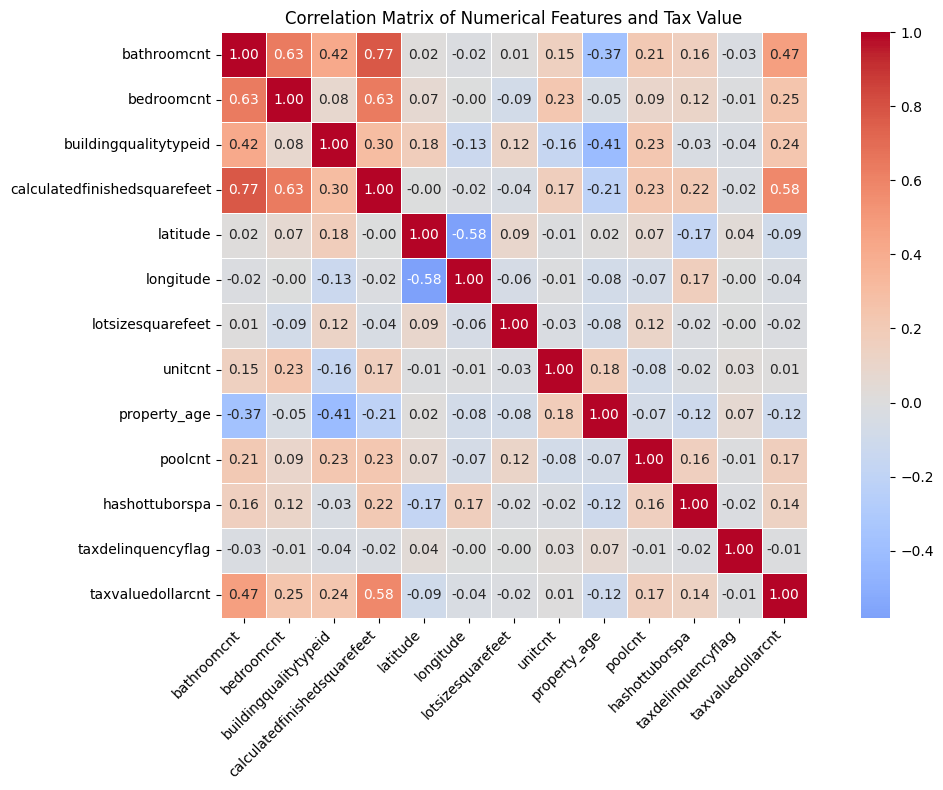

In [41]:
#Heatmap of the correlation matrix for numerical features
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",center=0, cbar=True, square=True, linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Correlation Matrix of Numerical Features and Tax Value")
plt.tight_layout()
plt.show()

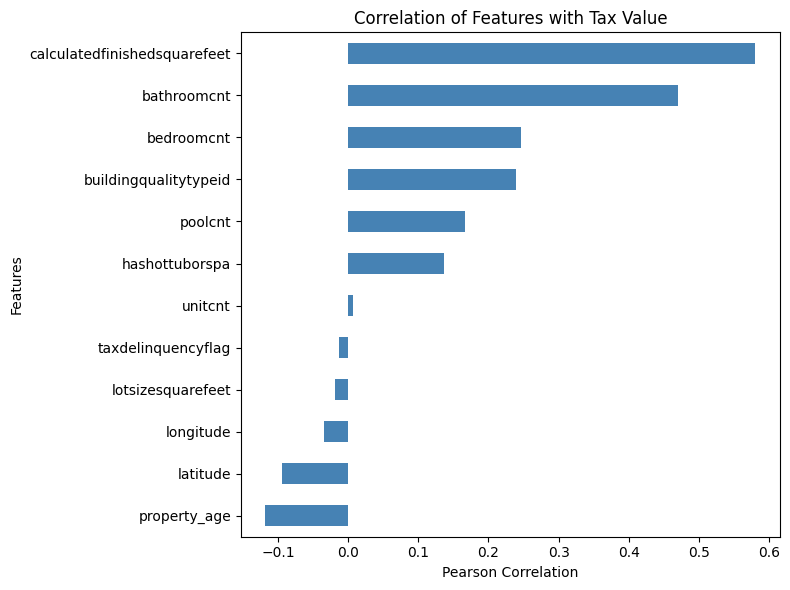

In [42]:
#Correlation of numerical features with the target
target_corr = corr_matrix["taxvaluedollarcnt"].drop("taxvaluedollarcnt")
target_corr = target_corr.sort_values()

#Bar plot of correlation with target variable
plt.figure(figsize=(8,6))
target_corr.plot(kind="barh", color="steelblue")
plt.title("Correlation of Features with Tax Value")
plt.xlabel("Pearson Correlation")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [43]:
#Highly correlated features
#Remove duplicate pairs and self-correlations

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

print("Highly correlated feature pairs:")
print(high_corr_pairs[high_corr_pairs > 0.7])

Highly correlated feature pairs:
bathroomcnt  calculatedfinishedsquarefeet    0.773564
dtype: float64


In [44]:
#For part 4a discussion
#F-statistics
#Use only numeric columns
X_numeric = X_train_imputed[corr_cols]

f_scores, p_values = f_regression(X_numeric, y_train)

f_results = pd.DataFrame({
    "Feature": X_numeric.columns,
    "F Score": f_scores,
    "P Value": p_values
})

f_results = f_results.sort_values(
    "F Score",
    ascending=False
)

f_results.head(10)

,Feature,F Score,P Value
3,calculatedfinishedsquarefeet,30853.606039,0.000000e+00
0,bathroomcnt,17174.279212,0.000000e+00
1,bedroomcnt,3911.693030,0.000000e+00
2,buildingqualitytypeid,3676.020742,0.000000e+00
9,poolcnt,1744.198165,0.000000e+00
10,hashottuborspa,1148.356147,2.208617e-249
8,property_age,857.276521,3.853014e-187
4,latitude,543.730327,9.814156e-120
5,longitude,74.426694,6.442348e-18
6,lotsizesquarefeet,20.392335,6.320058e-06


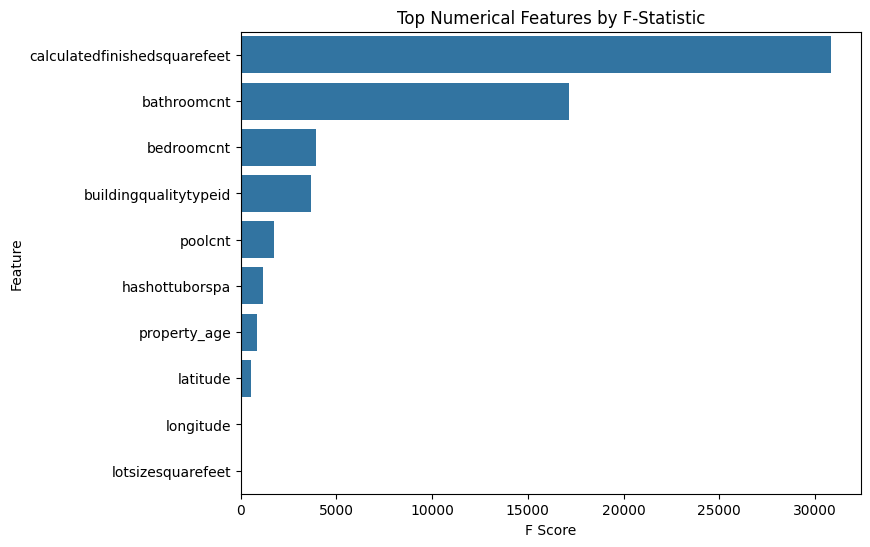

In [45]:
#F-score bar plot visualization
plt.figure(figsize=(8,6))

sns.barplot(
    data=f_results.head(10),
    x="F Score",
    y="Feature"
)

plt.title("Top Numerical Features by F-Statistic")
plt.show()

#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to be the strongest predictors of the target.
- Which pairs of features appeared to be highly correlated.
- Whether the correlation matrix and the F-statistics led you to similar conclusions about the most important features. Explain your reasoning.

> Replace this text with your answer.

The correlation analysis performed in this section showed that the strongest linear relationship with the target variable, taxvaluedollarcnt, came from calculatedfinishedsquarefeet. This result makes sense as larger homes tend to have higher assessed values. Other features with positive relationships with the target varibale included bathroomcnt, bedroomcnt, buildingqualitytypeid, and lotsizesquarefeet. Furthermore, these features describe the size, quality, and characteristics of a property, which are expected to influence its value. All of these relationships are seen in the correlation matrix heatmap. The strongest relationships were seen especially with calculatedfinishedsquarefeet and bedroomcnt or bathroomcnt which is expected because larger homes typically contain more bedrooms and bathrooms. These relationships indicate that some features contain overlapping information.

Features with weaker linear relationships with the target were likepoolcnt, hashottuborspa, and taxdelinquencyflag as they had relatively small correlations. This does not necessarily mean these features are useless because effects may be nonlinear or depend on interactions with other features. There could also be some sort of confounding varibale that is not being taken into account wiht the current dataset.

The F-statistics produced similar results to the correlation analysis. Features related to property size, especially calculatedfinishedsquarefeet, appear to be the strongest predictors in both analyses. This is suggestive of the features having a strong relationship with the target. However, correlation and F-statistics only measure individual linear relationships, so features like location variables may still be important even if their linear correlation is weak. Their predictive value may come from nonlinear patterns that will be explored with machine learning models in Milestone 2. Also at this stage, no features were removed or transformed based on these results as instructed in the directions.

4.B Discussion:
Describe what you learned from the three feature relationships you investigated.

For each pair, discuss:

The overall pattern you observed (for example, linear, nonlinear, weak, or strong).
What the relationship suggests about the features and their potential usefulness for predicting the target.
Whether your observations suggest possible feature engineering or preprocessing ideas that could be investigated in Milestone 2.
    Replace this text with your answer.

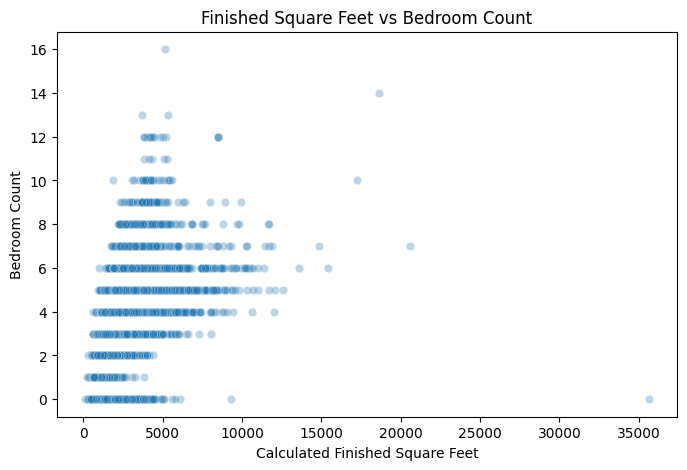

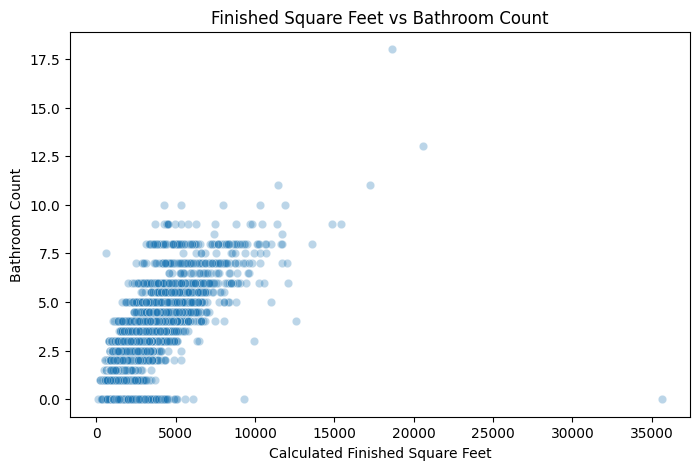

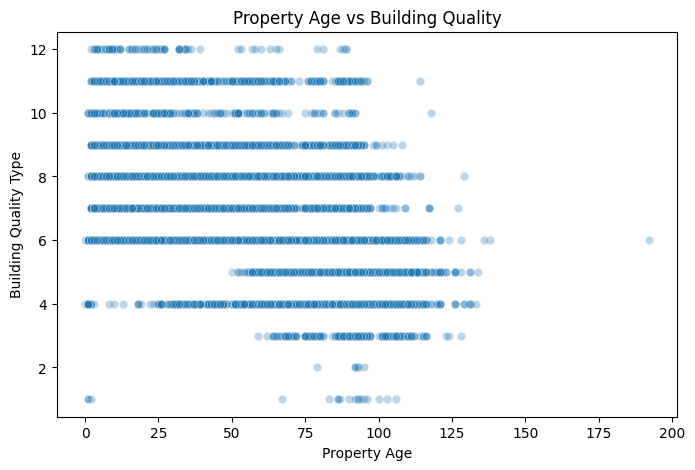

In [46]:
# Create a copy of the imputed training features for visualization
train_analysis = X_train_imputed.copy()

#Relationship 1: Finished square feet vs bedroom count
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=train_analysis,
    x="calculatedfinishedsquarefeet",
    y="bedroomcnt",
    alpha=0.3
)
plt.title("Finished Square Feet vs Bedroom Count")
plt.xlabel("Calculated Finished Square Feet")
plt.ylabel("Bedroom Count")
plt.show()

#Relationship 2: Finished square feet vs bathroom count
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=train_analysis,
    x="calculatedfinishedsquarefeet",
    y="bathroomcnt",
    alpha=0.3
)
plt.title("Finished Square Feet vs Bathroom Count")
plt.xlabel("Calculated Finished Square Feet")
plt.ylabel("Bathroom Count")
plt.show()

# Relationship 3: Property age vs building quality
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=train_analysis,
    x="property_age",
    y="buildingqualitytypeid",
    alpha=0.3
)
plt.title("Property Age vs Building Quality")
plt.xlabel("Property Age")
plt.ylabel("Building Quality Type")
plt.show()

#### **4.B Discussion:**

Describe what you learned from the three feature relationships you investigated.

For each pair, discuss:

- The overall pattern you observed (for example, linear, nonlinear, weak, or strong).
- What the relationship suggests about the features and their potential usefulness for predicting the target.
- Whether your observations suggest possible feature engineering or preprocessing ideas that could be investigated in **Milestone 2**.

> Replace this text with your answer.


The first relationship that was investigated was between the features calculatedfinishedsquarefeet and bedroomcnt. The plot showed a positive relationship, where properties with larger finished living areas generally had more bedrooms. However, the relationship was not perfectly linear because homes with similar square footage can have different numbers of bedrooms depending on their design/floorplan. This suggests that both features provide useful information but there are exceptions abotu the patterns found with property size and how many bedrooms it contains.

The second relationship that was investigated was between the features calculatedfinishedsquarefeet and bathroomcnt. This relationship also showed a positive trend. Larger properties generally had more bathrooms, which is expected because bigger homes usually have more rooms and amenities. Since these features describe related aspects of property size, they may contain repetitive information. It could be investigated in Milestone 2 whether combining these variables bedroomcnt and bathroomcnt into features such as square footage per bathroom or bedroom improves model performance.

The third relationship that was investigated was between the features property_age and buildingqualitytypeid. The relationship appeared weaker and is clearly not linear. Property age alone does not determine building quality because with older and newer homes, they may vary in quality. this quality can be but is not limited to high-quality construction or renovations. However, combining age with other features may provide useful information about property condition and value.

Overall, these feature relationships show that property size variables have strong relationships with each other, while characteristics such as age and quality may require additional feature engineering to capture their effect as linear realtionships can be limiting in information by themselves. These observations suggest possible future experiments with interaction features, feature combinations, and nonlinear models in Milestone 2.

## Part 5: Investigate Potential Feature Engineering [6 pts]

In this part, you will identify potential feature engineering and preprocessing techniques that **may** improve model performance.

The goal is to develop hypotheses based on your exploratory data analysis—not to permanently modify the dataset. In **Milestone 2**, you will evaluate these ideas experimentally and determine whether they actually improve the model.

**Important:** Do **not** permanently transform, remove, or add features in this milestone.

## Part 5.A: Identify Potential Feature Engineering Opportunities

Based on your exploratory analysis, identify **at least three (3)** feature engineering or preprocessing techniques that you believe may improve model performance.

Possible ideas include (but are not limited to):

- Log transformations
- Scaling or normalization
- Removing highly correlated features
- Polynomial features
- Interaction features
- Binning continuous variables
- Outlier removal
- Combining or aggregating existing features

You may investigate these ideas by creating visualizations or performing exploratory analyses, but **do not permanently modify the dataset**.

#### **5.A Discussion:**

Describe the three feature engineering or preprocessing ideas you identified.

For each one, explain:

- Which feature(s) it would affect.
- Why you believe it may improve model performance.
- How you would determine in **Milestone 2** whether it actually improves the model (for example, by comparing appropriate evaluation metrics on a validation or test set).

> Replace this text with your answer.

### Thoughts on possible feature engineering
We already changed the `yearbuilt` column to `property_age` in Part 3. We did this by subtracting yearbuilt from assessment year (2016).   
This makes the feature easier to understand because it shows how old the property is. Since we already did this earlier, we are not listing it as a new feature engineering idea in Part 5. 


* After transformation to numeric values for remaining categorical features in part 4, it looks like there is reasonably strong correlation between the target (taxvaluedollarcnt)

and the following features:
* calculatedfinishedsquarefeet
* bathroomcnt
* bedroomcnt
* buildingqualitytypeid
* fips

All of these seem to exhibit strong right skew and outliers, and most seem to have correlation with eachother as well (0.6 bedroom to bathroom, 0.77 bathroomcnt to square feet, etc.)
I was unsure about modifying fips, since it is a geographic code.
Likewise, building quality was reasonably normal distribution, so I did not think it would be best to tranform it without further understanding if it may bias the model.

The other features were numeric and somewhat correlated, and seemed like good candidates for transformation or removal.

Therefore, our initial 4 ideas are:

1. Log-transform right skewed variables with large outliers .

**This would impact:**  Target `taxvaluedollarcnt`, `bedroomcnt`, `bathroomcnt`, `calculatedfinishedsquarefeet`, `lotsizesquarefeet`. 

**This may improve model performance because:** All of these features seem to have reasonable correlation at first glance with the target variable. My hypothesis is this relationship may improve further if data is normalized.

**Would check it improves the model by:** Using evaluation metrics, such as linear regression, evaluating mean absolute error (MAE) or R2 score, or similar.

2. Create a new feature that summarizes related property information. Forexample, we could create total_rooms = `bedroomcnt` + `bathroomcnt`.

**This would impact:** `bedroomcnt`, `bathroomcnt`, or similar "room count" features if we do not drop them from analysis.

**This may improve model performance because:**  Combining them may improve the model performance.

**Would check it improves the model by:** Using evaluation metrics, such as R2 score/correlation to see if the overall correlation increased or decreased. It is unknown at this point, but it would be interesting to see if any other variables are affected.  

3. Create a new feature like ratio feature. it may also be usefull . Foreexample, we could create `calculatedfinishedsquarefeet` / `bedroomcnt`, `lotsizesquarefeet` / `bedroomcnt`   

**This would impact:** `calculatedfinishedsquarefeet` , `bedroomcnt` , `lotsizesquarefeet`  

**This may improve model performance because:** these ratio features can give more meaningful information about the property. For example, two homes may have the same number of bedrooms, but one may have much more living space. For example, there may be a threshold of the ratio of target/bedroomcnt where the relationship to the target may change  

**Would check it improves the model by:** comparing model performance with and without these new ratio features using MAE, RMSE , R2.

4. Bin values for target into ranges. 

**This would impact:** The target `taxvaluedollarcnt`

**This may improve model performance because:** This is because it is continous variable that has a handful of extreme outliers that will impact the model at the far end. 

However, since luxury homes are a valid category, it may not make sense to remove values.
Therefore, deciding on a reasonable (not too low) cutoff for "extreme" valued homes, may help with model stability.

**Would check it improves the model by:** Using evaluation metrics such as linear regresssion and MAE to see if the model improves.

### Lets try to evaluate a couple of these cases

In [47]:
# TO DO: correlation before and after log transform then try pairplots and perhaps linear regression


df_transform  =  pd.concat([X_train_imputed[corr_cols], y_train],axis=1)

df_transform['logbed'] = np.log1p(df_transform['bedroomcnt']).copy()
df_transform['logsqft'] = np.log1p(df_transform['calculatedfinishedsquarefeet']).copy()
df_transform['logbath'] = np.log1p(df_transform['bathroomcnt']).copy()
df_transform['logtax'] = np.log1p(df_transform['taxvaluedollarcnt']).copy()


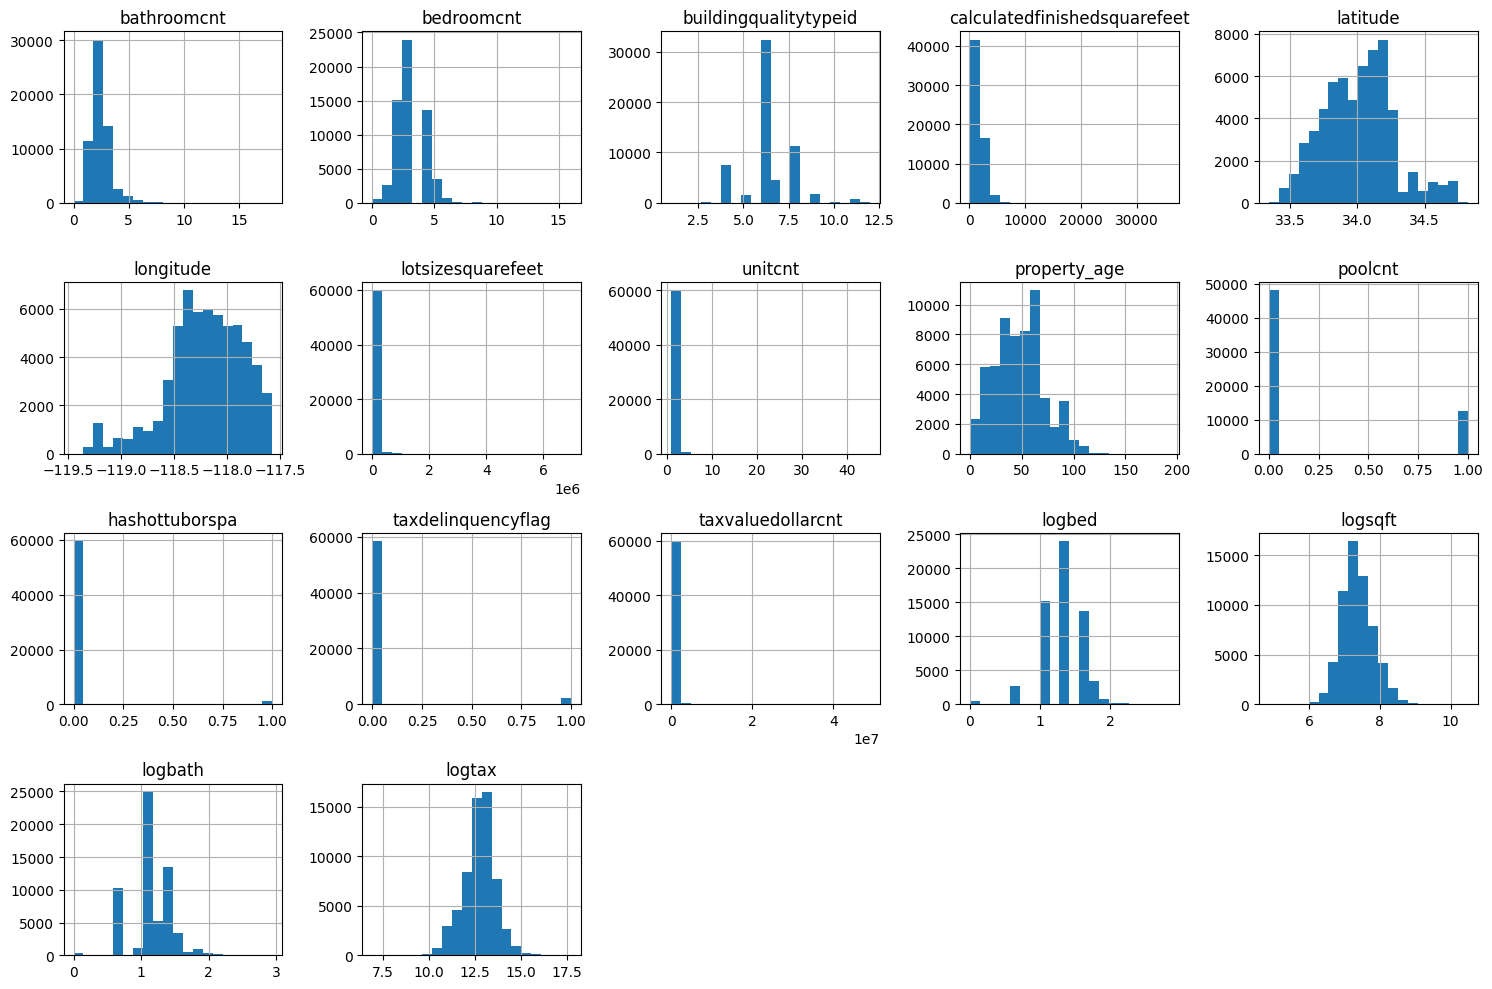

In [48]:
# Check shape - log tranforms look much more normal
df_transform.hist(figsize=(15, 10), layout=(-1, 5), bins=20)
plt.tight_layout()
plt.show()

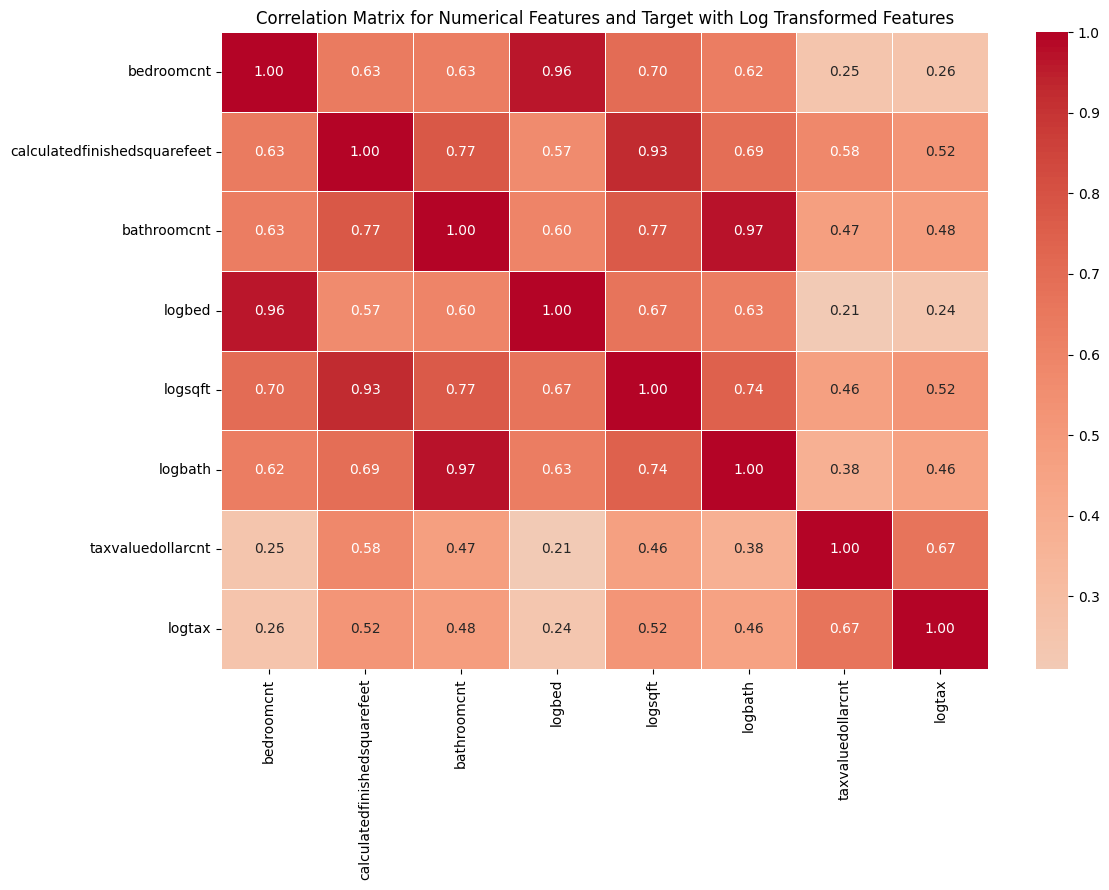

In [49]:
#Check correlation for transformed columns vs original
log_corr_cols = ['bedroomcnt','calculatedfinishedsquarefeet','bathroomcnt','logbed', 'logsqft','logbath','taxvaluedollarcnt', 'logtax']
plt.figure(figsize=(12, 9))

matrix_log = df_transform[log_corr_cols].corr()
sns.heatmap(matrix_log,cmap="coolwarm",center=0,annot=True,fmt=".2f",linewidths=0.5)

plt.title("Correlation Matrix for Numerical Features and Target with Log Transformed Features")
plt.tight_layout()
plt.show()

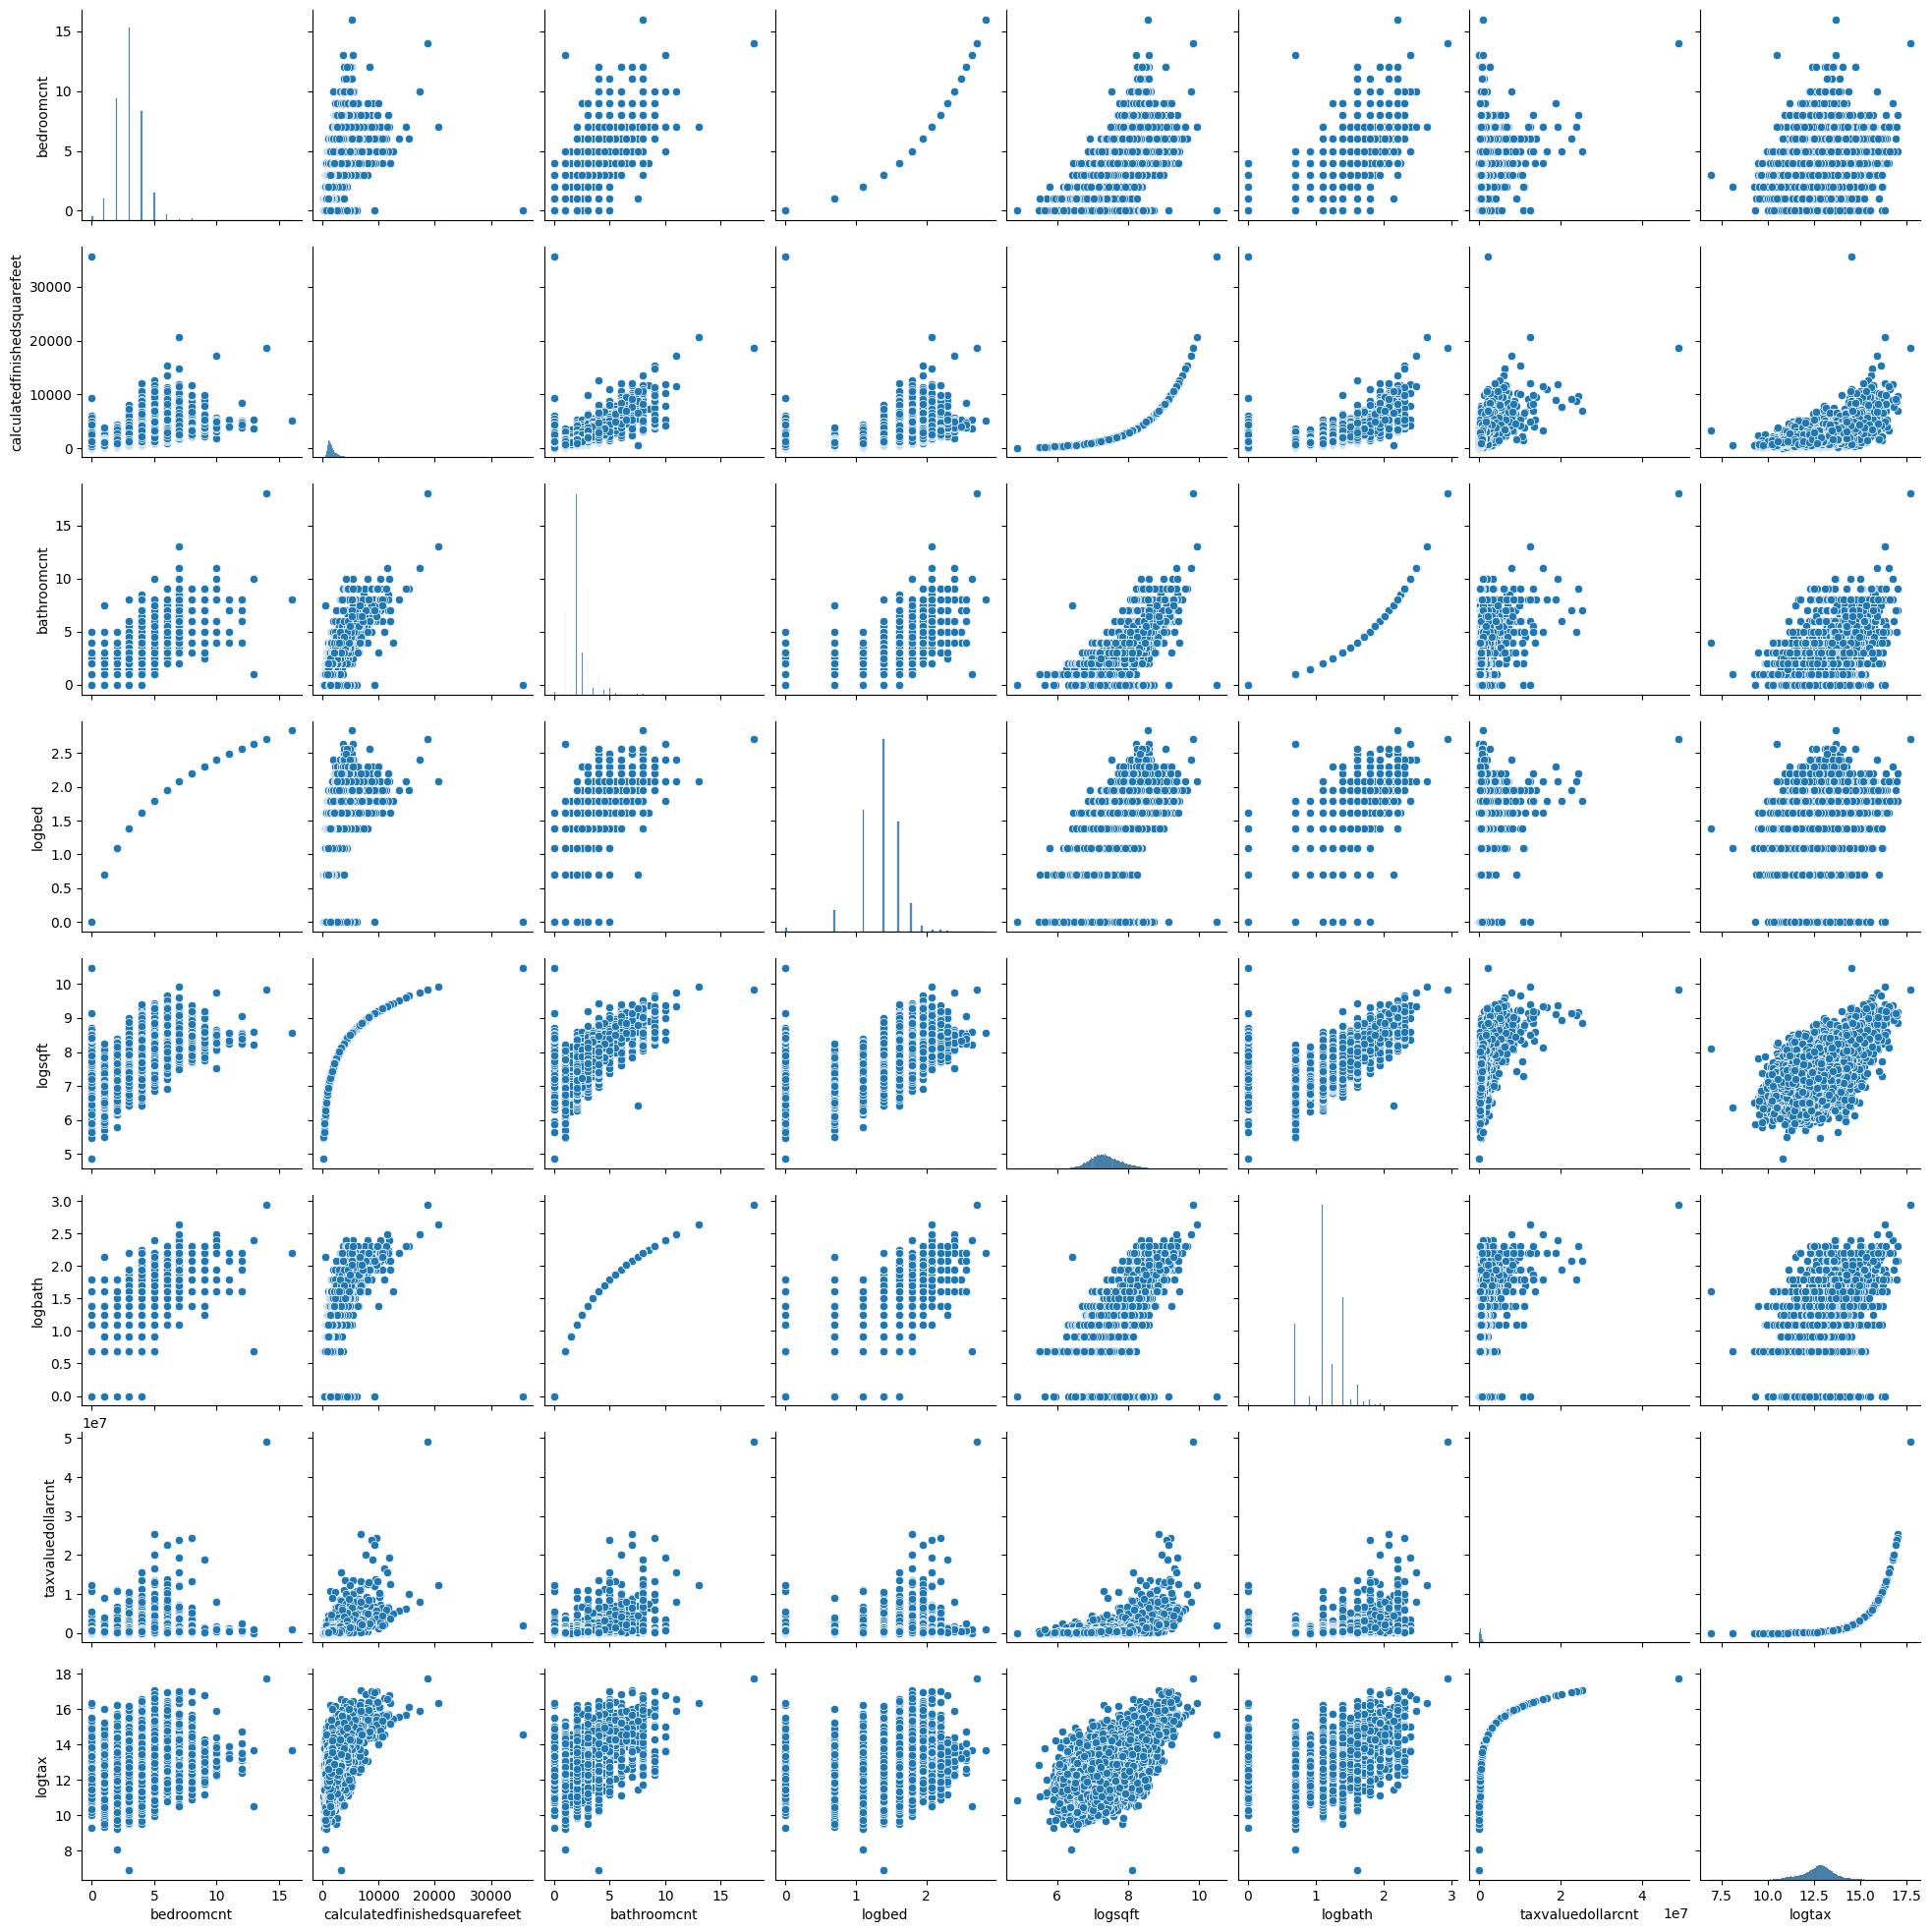

In [50]:
#Pairplots to assess any notable changes in pattern
sns.pairplot(df_transform[log_corr_cols])

#### Log transformation results are a mixed bag. 

Some correlations increased slightly, while others decreased slightly.

In the pairplots, it does appear that there is a slightly stronger linear pattern when visually assessing the original values vs the log transformed target.

There may be value in trying this however, perhaps with other features too.

In [51]:
#### Trying combining 2 features
df_transform['bedbathcnt'] = df_transform['bedroomcnt'] + df_transform['bathroomcnt']


In [52]:
#plot matrix of new features vs. old
cols = ['bedroomcnt','bathroomcnt','bedbathcnt','taxvaluedollarcnt','logtax']
add_matrix = df_transform[cols].corr()

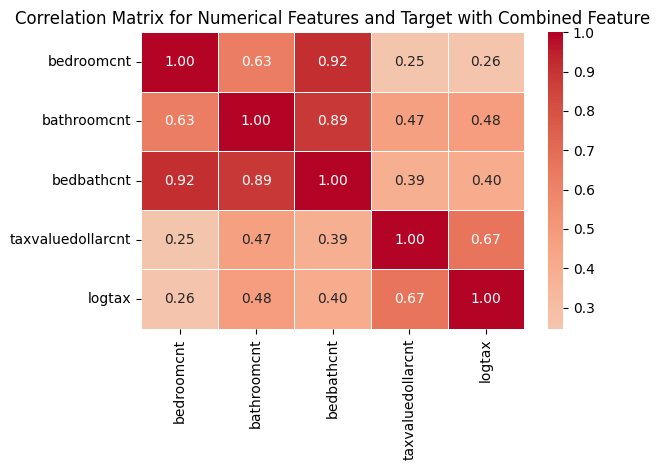

In [53]:
sns.heatmap(add_matrix,cmap="coolwarm",center=0,annot=True,fmt=".2f",linewidths=0.5)

plt.title("Correlation Matrix for Numerical Features and Target with Combined Feature")
plt.tight_layout()
plt.show()

### Feature combination results:

It appears that combining the columns did not amplify the correlation, but set the correlation to roughly the midpoint of the 2 features.

Though this did not improve the relationship, it could have some use if it turns out that either of these features has an outsized impact on model performance.

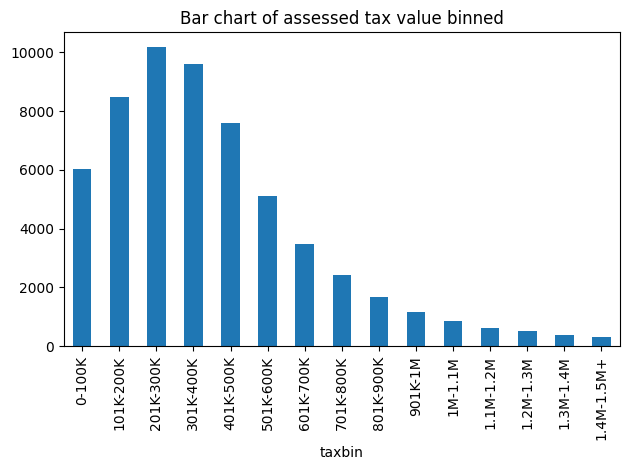

In [54]:
# Binning target instead of log transform.

bins = [0, 100000, 200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000, 1000000, 1100000, 1200000, 1300000, 1400000, 1500000]
labels = ['0-100K', '101K-200K', '201K-300K', '301K-400K', '401K-500K', '501K-600K', '601K-700K','701K-800K','801K-900K','901K-1M','1M-1.1M','1.1M-1.2M','1.2M-1.3M','1.3M-1.4M', '1.4M-1.5M+']

# Use pd.cut() to categorize the data.

df_transform['taxbin'] = pd.cut((df_transform['taxvaluedollarcnt']), bins=bins, labels=labels).copy()

# Visualize the Data

df_transform['taxbin'].value_counts(sort=False).plot(kind='bar')
plt.xticks(rotation=90)
plt.title('Bar chart of assessed tax value binned')
plt.tight_layout()
plt.show()

df_transform['taxbin'] = pd.cut((df_transform['taxvaluedollarcnt']), bins=bins, labels=False).copy()


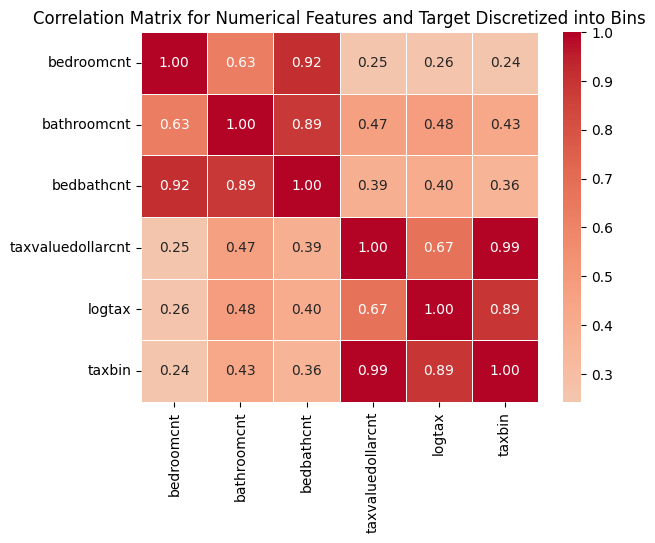

In [55]:
#Try correlation again with new variable vs original feature
#transform categorical data back to numeric for regression. Doesn't plot as nicely though.

df_transform['taxbin'] = pd.cut((df['taxvaluedollarcnt']), bins=bins, labels=False).copy()
cols2 = ['bedroomcnt','bathroomcnt','bedbathcnt','taxvaluedollarcnt','logtax','taxbin']
transform_corr = df_transform[cols2].corr()

sns.heatmap(transform_corr[cols2],cmap="coolwarm",center=0,annot=True,fmt=".2f",linewidths=0.5)

plt.title("Correlation Matrix for Numerical Features and Target Discretized into Bins")
plt.show()

## Findings: Correlation in this case seem to have improved over the original data

## Part 5.B: Prioritize Your Ideas

Not all feature engineering ideas are equally promising.

Based on your investigation, select the **two** ideas you believe are most likely to improve model performance.

Briefly explain why you selected these ideas over the others.

No code is required for this section.

#### **5.B Discussion:**

Suppose you had time to evaluate only **two** feature engineering or preprocessing ideas in **Milestone 2**.

For each one, explain:

- Which idea you would prioritize.
- Why you believe it is the most promising.
- What evidence from your exploratory analysis (such as feature distributions, missing values, feature relationships, or other observations) led you to this conclusion.

> Replace this text with your answer.

### Discussion on ideas to prioritize

Of the 4 ideas, after some thought, we would prioritize mostly likely.

**Prioritization and reasoning:** 
1. log transform of variables with large skew/outliers like calculatedfinishedsquarefeet, lotsizesquarefeet, Target variable.
2. Combining variables to new featuress like `total_room` =  `bedroomcnt` + `bathroomcnt` and `calculatedfinishedsquarefeet` / `bedroomcnt` .


**Why it seems promising:**
1. Log trnsformation may help, because some numerical variables have rightskewed  distributions and large outliers. A log transformation can reduce the effect of very large values. 
2. combined features may also help because several property size features are related to each other. for example `bedcount` and `bathcount` both describe the size and structure of the property. a feature like `total_rooms` may summarize this information in a simpler way

**Evidence from exploratory analysis**

The plot showed that some variables, like `calculatedfinishedsquarefeet`, `lotsizesquarefeet`, and the target , are skewed and have outliers.    
The correlation analysis also showed that `bedroomcnt`, `bathroomcnt`, and `calculatedfinishedsquarefeet` are related to each other and have some relationship with the Target.


#### **5 Discussion:** 

Describe in a paragraph why you chose these transformations and what you observed. 


**Discussion on transformations**

These transformations were chosen because log transforms seemed to be a simple way to reduce the effect of extreme outliers in right-skewed distributions. Once added back to a data frame, it was also fairly simple to review them with pairplots or correlation matrices to see if there were numeric changes in the relationships or visible shape changes.

Correlation was preferred because it is easy to interpret. Linear regression could have also been used, but based on the pairplots, not all relationships appear strongly linear, and correlation may be weak in some cases. Therefore, linear regression may not be the best first measure for this exploratory assessment.

Feature creation by combining features also seemed simple to test. For example, combining related features could create a new feature that summarizes similar property information. I was not sure of all the relationships since many features were dropped during EDA, but other feature creation ideas, such as multiplying related features or creating squared terms, could also be tested later.

Finally, binning the continuous target variable seemed like it could be helpful for visualization and interpretation. However, since the target is not an input feature, we would need to be careful not to use the binned target as a model feature. In this preliminary testing, binning did not seem to improve the relationship with the other features, which is why it was not chosen as one of the top two feature transformation ideas. It may still be useful for understanding the target distribution or depending on the modeling approach.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |



## Appendix 3: Flowchart for Identifying Feature Types

The following flowchart can help you identify the statistical type of each feature and determine an appropriate encoding strategy for categorical variables.

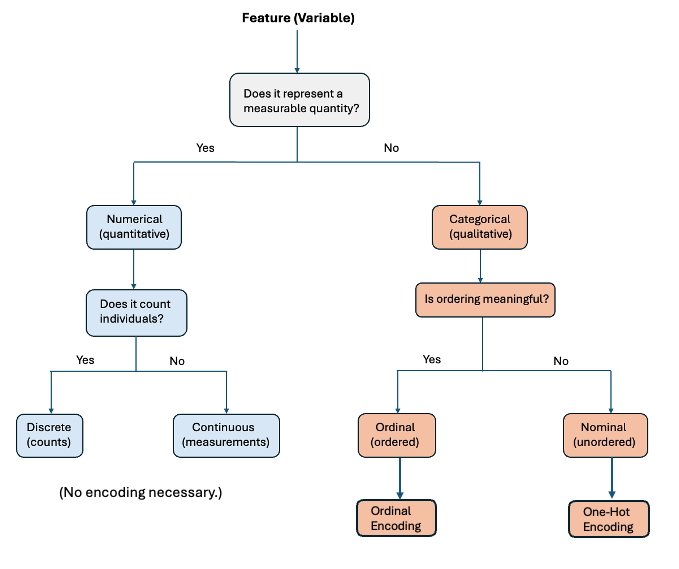